# OCC Video Message Decoding — Complete Analysis, Days 1 to 21

**Project:** Optical Camera Communication (OCC) — recovering a binary message from video of a
blinking light. TIH IIT Guwahati, 4-week online internship. Author: Keshav Prasad.

**Dataset:** the four supplied videos — `1LED_92bps`, `2LEDs_92bps`, `3LEDs_92bps`,
`4LEDs_92bps` (226 MB, 640×360, mpeg4, 260 fps).

This notebook is the whole project in one place. It is generated by `build_all.py` from the
day folders; every number it prints is computed from the videos when it runs, and every
claim it makes points at the day file that made it. It is organised in three parts:

| Part | Days | Kind | What it holds |
|---|---|---|---|
| I | 1–6 | planning, no data | The problem restated, the literature, the research question, the expected data, the plan, the methodology — and what the data later did to each |
| II | 7–16 | code, executed | Inspection, audit, ROI, EDA, pipeline, ablation, synchronisation, the beat, the threshold decoders |
| III | 17–21 | code, executed | ML classifier, method comparison, tuning, sensitivity study, best-candidate checkpoint |

| Section | Day | What it does |
|---|---|---|
| I.1–I.6 | 1–6 | Planning package (markdown) |
| 1 | 7 | Inspect the files: format, frame rate, integrity |
| 2 | 8 | Audit every frame: motion, visibility, ambient light |
| 3 | 9 | Find the lamps; choose how to read a bit |
| 4 | 10 | Explore the signal; test the stated bit rate |
| 5 | 11 | The extraction pipeline: video to brightness signal |
| 6 | 12 | Measure whether any cleaning step helps |
| 7 | 13 | Try to recover the symbol clock |
| 8 | 14 | The beat between the bit grid and the frame grid |
| 9 | 15 | Threshold decoder and consistency checks |
| 10 | 16 | Decoder v2: which bits survive an unknown phase |
| 11 | 17 | ML-assisted symbol decision |
| 12 | 18 | One comparison over every method |
| 13 | 19 | Controlled parameter experiments |
| 14 | 20 | Sensitivity / ablation study |
| 15 | 21 | Best-candidate checkpoint (TEST opened once) |
| 16 | — | What the project established |

**Read this before the results.** No ground truth was ever supplied — we have never been
told what message these videos carry. So nothing here measures whether a decoded bit is
**correct**. On the real videos every number is an internal consistency indicator: how
confident, how stable, how self-consistent. A decoder can score perfectly on all of them and
still be wrong about every bit. The only bit error rates in this notebook are on **synthetic**
signals built from the *assumed* model (Part III), and they measure how well a method decodes
that model, not the videos. Also: **92 bps comes from the filename.** It is an assumption;
Days 10, 13 and 16 found evidence against it and no other rate fits better.

**What the project found, in one paragraph.** The videos are clean and technically easy:
260 fps, a static camera, no drift, a near-binary signal, lamps found automatically. But the
level changes in the light fit a 92 bits-per-second grid no better than randomly chosen times
would, and no other rate does better — the symbol clock is not recoverable from these videos.
The decoders therefore work at an assumed rate and a declared phase; about 44% of each bit
stream is decided whatever the phase is. Building a synthetic generator (Day 17) exposed a
window bug in the sampling rule and, on Day 19, showed that the rule chosen on Day 9 is the
worst of three at an unknown phase — the "nearest frame to the bit centre" rule halves the
phase error and is immune to threshold placement. The sensitivity study (Day 20) found the
pipeline insensitive to ROI, smoothing and threshold, and hostage to one number it does not
have: the bit period, which must be known to 0.03% for a 3,000-bit message.

**Before running:** run from the repository root with the four videos in `data/raw/`
(`bash week01/day07/preserve_raw.sh Videos` makes that copy, fingerprints and locks it).
Nothing is ever written there. Part III reads the frozen `week02/day12/signal_v1/` and the
committed Week-3 modules. `ffprobe` is optional. `QUICK = True` in the first code cell
shortens every signal and coarsens every sweep so the notebook runs in a few minutes; the
committed copy was executed with `QUICK = False` (about 10 minutes). Reconstructed or
regenerated inputs are labelled as such in the day folders and in `AUDIT_CHANGELOG.md`.

# Part I — Days 1 to 6: the plan, before any data

These six days produced documents, not code. Each subsection gives what the day was asked
for, what it delivered, the content that mattered later, and — in the last row — what the
data did to it once it arrived on Day 7. The original files keep their text; every reversal
is a dated note in them, not an edit.

## I.1 Day 1 — Problem understanding and system definition

**Task.** Rewrite the problem statement in technical terms; identify inputs and the target;
draw the end-to-end pipeline; define success criteria; list at least eight clarifying questions.
**Delivered.** `week01/day01/PROBLEM_STATEMENT.MD`, `occ.png`.

**The problem, restated.** A lamp blinks in on-off keying; a frame-based camera samples it at
its own frame rate, unsynchronised to the bit clock, so the video holds an indirect, aliased
trace of the bitstream as frame-to-frame brightness in the lamp's region. Build a software-only,
offline pipeline that turns that video back into the bits and the message.

**Inputs / target.** Input: raw video; the *modelling unit* is the per-frame brightness of the
lamp region, sampled at the frame rate. Target: the bit sequence and the message it encodes.
Supporting outputs: BER where truth exists, synchronisation robustness, runtime.

**Pipeline, as first drawn.** video → frame extraction → transmitter localisation (ROI, tracked
if the camera moves) → intensity extraction (one scalar per frame) → preprocessing (denoise,
normalise, detrend) → symbol synchronisation (recover the bit clock; "likely the hardest
step") → threshold / classification → decoding and evaluation.

**Success criteria.** Decoded-message correctness; BER; synchronisation robustness under
frame-rate / symbol-rate mismatch; sensitivity to ROI, smoothing, threshold and timing
choices, reported rather than hoped for; execution time; reproducibility.

**The ten questions** (the ones that mattered most): what are the frame rate and symbol rate,
and is the ratio fixed? — how many videos have ground truth? — is the ROI static or moving? —
is there framing above the raw bits (preamble, parity, Manchester)? — rolling or global
shutter? — how are the videos diverse? — what labels exist for the ML arm? — codec?

| What the data did to it | |
|---|---|
| Frame rate | 260 fps, not 30–60 (Day 7) — per-frame decoding is possible; stripe decoding out of scope |
| Ground truth | none, for any video (Day 7 §5.1) — correctness and BER unmeasurable on real data, the ML arm has no labels |
| ROI | static camera (Day 8) — no tracking needed |
| Framing | unknown; decoded bits are not text and not Manchester (Day 7 §5.2) — still unknown on Day 21 |
| Symbol rate | 92 bps from the filename only; the data argue against it (Days 10, 13) |

## I.2 Day 2 — Literature review: domain and ML

**Task.** Core concepts across CV / optical communication / signal processing / ML; 6–10
related methods; a comparison table (data, approach, metrics, results, limitations); a
candidate-method shortlist including a fixed/adaptive threshold baseline, a signal-processing
pipeline, and a simple ML classifier where labels permit.
**Delivered.** `week01/day02/DAY_02.MD`, `methods.png`.

**Concepts mapped.** *CV:* ROI localisation and tracking, blob/contour detection, rolling-shutter
geometry (sub-frame information as stripes). *OCC/VLC:* on-off keying; undersampled schemes
(UFSOOK, UPSOOK) built for 30–60 fps cameras; rolling-shutter stripe decoding; DC-balanced line
codes (Manchester, 4B6B, 8B10B); IEEE 802.15.7. *Signal processing:* sampling and aliasing —
the frame rate is the sampling clock and is not synchronised to the symbol clock, which is the
crux of "symbol synchronisation"; adaptive thresholding and detrending against ambient and
auto-exposure drift; interleaving against inter-frame gaps. *ML:* CNN symbol classifiers,
transfer learning on small OCC datasets, learned ROI detection.

**Comparison table** (`methods.png`, six systems): UFSOOK (Roberts) — bit rate capped near half
the frame rate, ~15 bit/s at 30 fps, no ROI-robustness study; UPSOOK — phase-based, needs two
synchronised LEDs; rolling-shutter colour-shift keying — BER vs ambient light and sampling
position; NoGap rolling shutter — ~6.4 kbit/s at 3 m, needs exposure-timing control; 4-level
PWM rolling shutter — row-readout period estimated from the images, depends on auto-exposure;
CNN demodulation — transfer learning on small custom datasets. Ten papers were reviewed in all
(Danakis 2012, Roberts 2013, Luo 2014, Nguyen 2015, Ji 2014, Chow 2015 / Liu 2016, Chuang
2019, Hsu 2020, Peng 2023, Saeed 2019); six systems are tabulated. The gap none of them fills:
*how far can the settings be off before decoding fails* — which became this project's own
experiment.

**Shortlist.** (1) Fixed-threshold baseline — simple, brittle to drift. (2) Adaptive
signal-processing pipeline — rolling threshold, detrending, symbol-boundary recovery; "the
natural main baseline". (3) Lightweight ML symbol classifier — logistic regression / small
CNN / SVM on windowed intensity features, only where labels exist.

| What the data did to it | |
|---|---|
| Undersampled / stripe methods | Irrelevant at 260 fps with a global-shutter-like signal (Day 7) |
| Drift handling (2) | Nothing to handle: ambient ≈ 0.1% of contrast, on-level moves 0.13 grey levels (Days 8, 10); detrend/normalise measured harmful (Day 12) |
| ML classifier (3) | No labels ever arrived; built on synthetic labels and on the threshold decoder's own safe bits (Day 17) |

## I.3 Day 3 — Research framing and mentor review

**Task.** Refine the research question with measurable outputs; a ≤3-slide progress pack
(completed work, findings, blockers, next plan); confirm target, dataset structure, metrics
and scope with the mentor; record decisions.
**Delivered.** `week01/day03/DAY_03.MD`, `Keshav_Day03_PPT.pdf` (title + 3 slides).
**Not delivered:** mentor notes — none were recorded; `MENTOR_NOTES.MD` is a blank template.

**Research question.** *How accurately and robustly can a fully offline, software-only pipeline
recover a transmitted OOK binary message from unsynchronised camera video of a blinking light
source, comparing classical signal-processing decoding against a lightweight ML-assisted
symbol classifier, across variation in ROI selection, ambient/exposure conditions, and
symbol-timing assumptions?*

**Measurable outputs.** Decoded-message correctness (% of videos exactly right); BER where
reference bits exist; synchronisation robustness as a *tolerance range*, not one number;
execution time per video per method; sensitivity curves of BER against ROI size/position,
smoothing window, threshold and timing offset.

**Blockers on the slide.** Dataset not received (frame rate, symbol rate, labels unknown);
unknown framing above the bits; ROI static or moving; ML label granularity.

| What the data did to it | |
|---|---|
| Message correctness, BER | Unmeasurable on real data — no truth (Day 7). Measured on synthetic signals only (Days 17–21) |
| Robustness as ranges | Delivered on Day 20: ROI 0.5–2×, threshold ±30% of range, phase −0.4 to +0.2 bit, period ±0.03% |
| The four blockers | All answered by the data itself on Day 7; none by a mentor record |

## I.4 Day 4 — Dataset schema, structure and risk assessment (pre-dataset)

**Task.** Define expected files/columns/labels/metadata; list missing-data, annotation,
imbalance, temporal and leakage risks; define what a correct train/validation/test split must
preserve; a risk checklist.
**Delivered.** `week01/day04/DAY_04.MD`.

**Expected data.** `data/raw/` immutable and checksummed; `.mp4` at 30 or 60 fps, 720p–1080p,
tens to hundreds of frames per message; ground truth most likely per message, possibly per
symbol, unlikely per frame; a per-video manifest with `fps_declared` vs `fps_measured`,
`symbol_rate_bps` (faculty), `fps_to_symbol_ratio` ("the single most important number in the
project"), `message_text`, `encoding_scheme`, `polarity`, `session_id`.

**Risks named.** Dropped/duplicated frames and variable frame rate (break the sampling clock);
ROI loss; saturation at 255; missing symbol rate ("symbol synchronisation becomes blind
estimation"); off-by-one and polarity ambiguity in any BER; undocumented framing; bit-class
and run-length imbalance; within-video autocorrelation (never split by frame); slow drift;
rolling-shutter sub-frame structure; aliasing if the symbol rate approaches Nyquist; six leakage
routes, from same-video splits to *truth-aided synchronisation* ("makes any decoder look
excellent — label it an oracle bound").

**Split rule.** Split unit = the video (or session), never the frame; condition coverage in
every split; message disjointness; temporal order preserved; fixed seed; if too few videos,
leave-one-video-out with one or two held out, and say the sample is small.

| What the data did to it | |
|---|---|
| 30–60 fps, 720p+ | 260 fps, 640×360 (Day 7) |
| Ground truth per message | None at any granularity |
| `fps_to_symbol_ratio` | 2.826 *if* the filename is right — and the run lengths say it is not (Day 10) |
| Saturation | Every lamp clips at 255 — harmless for on/off (Day 7 §5.5) |
| By-video split | **Cannot be applied:** four videos, four different setups, one per condition. Replaced by a within-video time split — first 30% DEV, last 70% TEST (Day 7 §6; used Days 17–21) |
| Aliasing risk | Real: the clock cannot be found at any rate (Day 13); a short exposure (~0.3 frame) makes a wrong phase invisible (Day 17) |

## I.5 Day 5 — Pipeline and experiment planning

**Task.** A reproducible workflow from raw data to final evaluation; baseline, advanced and
project-specific experiment; tentative evaluation criteria (correctness, BER, synchronisation
robustness, execution time); an experiment-log template; a repository/folder structure.
**Delivered.** `week01/day05/DAY_05.MD`, `EXPERIMENT_PLAN.MD` (E01–E16), `EXPERIMENT_LOG.MD`.

**Workflow.** Eight stages, each saving its output so any one can be re-run alone: read frames →
find the light (variance map → ROI → tracker) → brightness per frame → clean (detrend,
normalise, smooth) → bit timing (frames per bit + start offset) → 0/1 decision → bits to
message → score. `data/raw/` read-only. A synthetic OOK video maker as backup ground truth,
with the non-integer `sps = 3.7` case singled out as "the closest fake copy of the real
unsynchronised problem".

**Methods.** *M0* fixed threshold, majority vote per bit, timing assumed from config — "meant
to be simple, not good". *M1* variance-map ROI + CSRT tracker, brightest-p% mean, detrend,
rolling normalise, short smooth, `sps` from autocorrelation/FFT, phase by widest on/off
separation, rolling-median threshold with hysteresis, preamble search. *M2* logistic regression
→ RBF SVM → small 1-D CNN on windows around bit centres, only with labels (Gate G4); split by
video. **The project's own experiment:** measure how far ROI, cleaning, threshold and timing
can be wrong before decoding fails; report working ranges; compare how M1 and M2 degrade.

**Metrics.** MCR and normalised edit distance; BER with polarity and alignment offset reported
("BER alone cannot tell a timing slip from wrong bits"); phase and rate tolerance bands where
BER ≤ 0.01; seconds per video and ms per frame, median of 3; a `metrics.json` per run, tables
built from those files, "a hand-typed number counts as a bug".

**Gates.** G1 data usable; G2 M0 runs; G3 M1 beats M0 on most videos; G4 M2 allowed only with
labels; G5 sensitivity study only if M1 works on one real video.

**Folder structure.** `configs/`, `data/{raw,synthetic,interim,ground_truth}`, `src/occ/{io,roi,
signal,decode,ml,eval,synth}`, `scripts/`, `runs/<run_id>/`, `experiments/`, `reports/`, `tests/`.

| What the data did to it | |
|---|---|
| M1's detrend / normalise / smooth | All three switched off on Day 9 and measured harmful on Day 12 (every option halves the separation; a 3-frame smoother deletes 27% of transitions) |
| M1's tracker; "first K frames" ROI | Camera static — tracker off; ROI must sample the whole clip (4LEDs is dark for its first 1,816 frames) |
| M2 | Never ran as planned — no labels; built on synthetic truth on Day 17 |
| Gate G3 | Unevaluable without BER; fixed and adaptive thresholds agree on 97–99% of bits (Days 15, 18) |
| Gate G4 | Failed outright |
| Folder structure | Designed, never adopted — the repository uses one folder per day |
| The `sps = 3.7` synthetic case | Vindicated: the real ratio is 2.826, and Day 17's generator is that plan built |

## I.6 Day 6 — Pre-dataset readiness and mentor review

**Task.** Complete the literature, methodology and data-readiness package; present
preprocessing, modelling and evaluation; confirm split, metrics, constraints and scope with the
mentor; incorporate feedback into Methodology V1; update the experiment plan.
**Delivered.** `week01/day06/DAY_06.MD` (the four Day 5 deliverables, v2), `EXPERIMENT_PLAN_V2.MD`
(E00–E19), `METHODOLOGY_V1.MD` (**reconstructed** from the Day 4–6 text during the audit — the
original was never committed). **Not delivered:** mentor corrections — none recorded.

**What v2 added.** FAKE / DEV / TEST data roles for every experiment; **E00 data-readiness
check** (inventory, SHA-256, frame rate two ways, fixed-or-variable rate, real frame count,
resolution, codec, saturation, stripes, light visibility, movement, ground-truth format; every
video gets a green/amber/red verdict before anything runs); **E17 leak check** (prove the split
rules were followed); **E18 timing-estimate accuracy** as a result in its own right; **E19 the
single TEST evaluation**, logged. Cut order fixed in advance: never cut E00–E05, E10, E16, E17,
E19; cut the ML branch first.

**Methodology V1, §6.3 role rule.** Group videos by condition; hold out one or two as TEST so
every TEST condition also appears in DEV; leave-one-video-out inside DEV; write the TEST IDs in
the log before any tuning.

| What the data did to it | |
|---|---|
| E00 | Run on Day 7 — with a capped scan whose frame-count warning was an artefact, corrected on Day 8 and in the audit |
| §6.3 role rule | Cannot be applied to four single-condition videos; within-video time split instead (Day 7 §6) |
| E17 / E19 | Realised as the Day 19 selection discipline and the single TEST opening on Day 21 |
| E18 | Became Days 13 and 19–20: the timing estimate cannot be made from the videos; the tolerance to a wrong period is ±0.03% |
| E11 (noise/drift/compression, fake only) | Noise and exposure varied on the synthetic model (Days 17–20); drift and compression not exercised |

In [2]:
import os, json, hashlib, subprocess, time, itertools
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

RAW = Path('data/raw')
FPS = 260.0          # measured in section 1 - not assumed
BPS = 92.0           # taken from the FILENAME. Sections 4, 7 and 8 test it and fail to confirm it
T92 = FPS / BPS      # frames per bit if the filename is right

# QUICK=True keeps the sweeps coarse and the signals short so the notebook runs
# in a few minutes. Set it to False to reproduce the exact numbers in the reports.
QUICK = False

plt.rcParams['figure.dpi'] = 110
videos = sorted(RAW.glob('*.mp4'))
print(f"videos found: {len(videos)}")
for v in videos:
    print("  ", v.name, f"{v.stat().st_size/1e6:.1f} MB")
assert videos, "put the four .mp4 files in data/raw/ first"
print(f"\nif the filename is right, one bit lasts {T92:.4f} frames")

videos found: 4
   1LED_92bps.mp4 101.9 MB
   2LEDs_92bps.mp4 62.1 MB
   3LEDs_92bps.mp4 34.0 MB
   4LEDs_92bps.mp4 37.9 MB

if the filename is right, one bit lasts 2.8261 frames


## 1. Day 7 — Inspect the files

> **Task.** Preserve an immutable raw copy; inspect files, frames, labels, metadata; check missing/invalid/duplicate data; first-look statistics; no irreversible cleaning.
> **Delivered.** `week01/day07/`: `preserve_raw.sh` + `SHA256SUMS`, `inspect_dataset.py` + `reports/`, `DATASET_MANIFEST.csv`, `DAY_07_FINDINGS.MD`.
> **Status.** Correct after correction: the manifest was a capped scan (artefact), and the claim that the run lengths *confirmed* 2.83 frames per bit was wrong — the histogram omitted the 1-, 4- and 7-frame runs that cannot occur at that rate. See section 4.

Before any analysis: what are these files, and can we trust them?

The frame rate matters more than anything else, because everything downstream depends on
it. We check it three ways: what the file claims, whether the claim is self-consistent, and
whether the frames are really evenly spaced in time.

In [3]:
def sha256_file(p, chunk=1<<20):
    h = hashlib.sha256()
    with open(p,'rb') as f:
        while True:
            b = f.read(chunk)
            if not b: break
            h.update(b)
    return h.hexdigest()

def probe(path):
    cmd = ['ffprobe','-v','error','-select_streams','v:0','-show_entries',
           'stream=codec_name,width,height,r_frame_rate,avg_frame_rate,nb_frames,pix_fmt',
           '-show_entries','format=duration','-of','json',str(path)]
    try:
        out = subprocess.run(cmd, capture_output=True, text=True, timeout=120)
        return json.loads(out.stdout) if out.returncode==0 else {}
    except Exception:
        return {}

def rate(txt):
    if not txt: return None
    if '/' in txt:
        a,b = txt.split('/')
        return float(a)/float(b) if float(b) else None
    return float(txt)

print(f"{'video':16s} {'codec':8s} {'size':11s} {'r_rate':>8s} {'avg':>8s} "
      f"{'frames':>7s} {'dur s':>8s} {'frames/dur':>11s}")
have_ffprobe = bool(probe(videos[0]))
if not have_ffprobe:
    print("(ffprobe not found - falling back to OpenCV header fields; the two container")
    print(" rate fields cannot be compared on this machine)")
for v in videos:
    p = probe(v); st = p.get('streams',[{}])[0]
    dur = float(p.get('format',{}).get('duration',0) or 0)
    nb  = int(st.get('nb_frames',0) or 0)
    if not have_ffprobe:                      # audit: OpenCV fallback instead of a crash
        cap = cv2.VideoCapture(str(v))
        st = {'codec_name': 'n/a', 'width': int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
              'height': int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
              'r_frame_rate': str(cap.get(cv2.CAP_PROP_FPS)),
              'avg_frame_rate': str(cap.get(cv2.CAP_PROP_FPS))}
        nb = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); dur = nb / float(cap.get(cv2.CAP_PROP_FPS))
        cap.release()
    print(f"{v.stem:16s} {str(st.get('codec_name')):8s} "
          f"{st.get('width')}x{st.get('height'):<6d} {rate(st.get('r_frame_rate')):8.1f} "
          f"{rate(st.get('avg_frame_rate')):8.1f} {nb:7d} {dur:8.2f} "
          f"{nb/dur if dur else 0:11.2f}")
print("\nThe two rate fields agree, and frames divided by duration agrees with both.")
print("If they disagreed the video would have a variable frame rate, the frames would")
print("not be evenly spaced in time, and every timing result below would be invalid.")
print(f"\nfingerprint of {videos[0].name}: {sha256_file(videos[0])[:16]}...")

video            codec    size          r_rate      avg  frames    dur s  frames/dur
(ffprobe not found - falling back to OpenCV header fields; the two container
 rate fields cannot be compared on this machine)
1LED_92bps       n/a      640x360       260.0    260.0   30058   115.61      260.00
2LEDs_92bps      n/a      640x360       260.0    260.0   21157    81.37      260.00
3LEDs_92bps      n/a      640x360       260.0    260.0   13057    50.22      260.00
4LEDs_92bps      n/a      640x360       260.0    260.0   11033    42.43      260.00

The two rate fields agree, and frames divided by duration agrees with both.
If they disagreed the video would have a variable frame rate, the frames would
not be evenly spaced in time, and every timing result below would be invalid.

fingerprint of 1LED_92bps.mp4: ec24d5ecbb2c82f0...


In [4]:
# Are any frames simply repeated? That happens when a video is padded up to a
# higher frame rate, and it would make the 260 fps meaningless.
cap = cv2.VideoCapture(str(videos[0])); prev=None; dup=0; n=0
while n < 2000:
    ok, f = cap.read()
    if not ok: break
    g = cv2.cvtColor(f, cv2.COLOR_BGR2GRAY)
    if prev is not None and np.array_equal(g, prev): dup += 1
    prev = g; n += 1
cap.release()
print(f"{videos[0].stem}: {n} frames checked, {dup} identical to the one before")
print("Zero repeats, so the 260 fps is genuine content, not padding.")

1LED_92bps: 2000 frames checked, 0 identical to the one before
Zero repeats, so the 260 fps is genuine content, not padding.


## 2. Day 8 — Audit every frame

> **Task.** Audit frame rate, duration, resolution, readability, corruption; camera motion, visibility, ambient light, occlusion; a quality/risk table; preserve originals.
> **Delivered.** `week02/day08/DAY_08.MD` (quality table, risks R1–R13), `audit_videos.py` reproducing the table.
> **Status.** Every number verified on a full 75,305-frame read. Two risks were real and were fixed downstream: the 2LEDs false start (trim on sustained activity) and per-lamp ROIs.

One pass over each video collecting the brightest pixel per frame (for trimming and
visibility), where the bright pixels sit (motion), and the background level (ambient
light).

In [5]:
def audit(path, max_frames=None):
    cap = cv2.VideoCapture(str(path))
    fmax, amb, cx, cy, lit = [], [], [], [], []
    n = 0
    while True:
        ok, f = cap.read()
        if not ok: break
        g = cv2.cvtColor(f, cv2.COLOR_BGR2GRAY)
        fmax.append(int(g.max()))
        bright = g > 180
        nb = int(bright.sum())
        amb.append(float(g[~bright].mean()) if nb < g.size else float(g.mean()))
        if nb > 20:
            ys, xs = np.nonzero(bright)
            cx.append(xs.mean()); cy.append(ys.mean()); lit.append(n)
        n += 1
        if max_frames and n >= max_frames: break
    cap.release()
    return dict(fmax=np.array(fmax), amb=np.array(amb), cx=np.array(cx),
                cy=np.array(cy), lit=np.array(lit), n=n)

cap_frames = 6000 if QUICK else None
A = {}
for v in videos:
    A[v.stem] = audit(v, cap_frames)
    a = A[v.stem]
    print(f"{v.stem:16s} {a['n']:6d} frames read, lamp lit in {len(a['lit']):6d} of them")
if QUICK:
    print(f"\n(QUICK mode: only the first {cap_frames} frames of each video)")

1LED_92bps        30058 frames read, lamp lit in  13564 of them
2LEDs_92bps       21157 frames read, lamp lit in  12133 of them
3LEDs_92bps       13057 frames read, lamp lit in   8519 of them
4LEDs_92bps       11033 frames read, lamp lit in   7186 of them


In [6]:
print("Camera motion, measured on the single-lamp video where the centre of the")
print("bright pixels really is one lamp:\n")
a = A[videos[0].stem]
nb = 20; bs = max(1, len(a['cx'])//nb)
bx = np.array([a['cx'][i*bs:(i+1)*bs].mean() for i in range(nb)])
by = np.array([a['cy'][i*bs:(i+1)*bs].mean() for i in range(nb)])
print(f"   slow drift across the clip: x {bx.max()-bx.min():.2f} px, y {by.max()-by.min():.2f} px")
print("   The camera is static, so no ROI tracking is needed.\n")
print("   On multi-lamp videos this same measure shows 8-10 px of apparent movement,")
print("   but nothing moved: the centre of ALL bright pixels jumps between lamps as")
print("   different ones light up. The measure is the wrong shape for that scene.\n")

print("Ambient light:\n")
for name, a in A.items():
    amb = a['amb']; blk = int(FPS); k = len(amb)//blk
    if k > 1:
        b = amb[:k*blk].reshape(k, blk).mean(1)
        print(f"   {name:16s} ambient {np.median(amb):5.2f}, varies by "
              f"{b.max()-b.min():.2f} across the clip")
print("\nAmbient moves well under one grey level against a lamp contrast of about 245.")
print("That is why detrending and normalising are switched off in section 6.")

Camera motion, measured on the single-lamp video where the centre of the
bright pixels really is one lamp:

   slow drift across the clip: x 0.15 px, y 0.76 px
   The camera is static, so no ROI tracking is needed.

   On multi-lamp videos this same measure shows 8-10 px of apparent movement,
   but nothing moved: the centre of ALL bright pixels jumps between lamps as
   different ones light up. The measure is the wrong shape for that scene.

Ambient light:

   1LED_92bps       ambient  3.51, varies by 0.71 across the clip
   2LEDs_92bps      ambient  2.55, varies by 0.56 across the clip
   3LEDs_92bps      ambient  2.41, varies by 0.87 across the clip
   4LEDs_92bps      ambient  1.67, varies by 0.86 across the clip

Ambient moves well under one grey level against a lamp contrast of about 245.
That is why detrending and normalising are switched off in section 6.


## 3. Day 9 — Find the lamps, and choose how to read a bit

> **Task.** Candidate ROIs and intensity plots; confirm detection/extraction strategy; define synchronisation and evaluation; freeze preprocessing.
> **Delivered.** `week02/day09/`: `roi_extract.py`, `rois.json`, `ROI_CANDIDATES.MD` (five-criterion box comparison), the sampling-rule study, frozen preprocessing (cleaning off), 3-slide PDF.
> **Status.** Lamps found automatically in all four videos. **Two reversals later:** "bit rate confirmed from run lengths" was wrong (Day 10), and the sampling rule chosen here — most confident frame, sold as phase-insensitive — is exactly what makes the phase unobservable (Day 15) and is the worst of three at an unknown phase (Day 19).

### Finding the lamps

The lamps sit close together, so a shape-based rule merges them. What separates them is
**behaviour**: pixels of one lamp blink together, pixels of different lamps do not.

Two details that were bugs before they were features:

- Sample frames from across the **whole** clip. If the message opens with a long run of one
  bit, the first frames show no change at all and the search finds nothing.
- Reject groups that are not solid discs. A lamp fills its own box; halo and glare do not.

In [7]:
def sustained_bounds(fmax, win_s=1.0, need=0.15, lit_level=180):
    """Trim on sustained activity, not the first bright frame. One video has a
    single flash followed by 3.4 seconds of dark; trimming on the first bright
    frame would feed that silence to the decoder."""
    w = max(1, int(FPS*win_s))
    lit = (fmax > lit_level).astype(np.float32)
    if len(lit) < w: return 0, len(lit)-1
    run = np.convolve(lit, np.ones(w)/w, mode='valid')
    ok = np.flatnonzero(run >= need)
    if not len(ok): return 0, len(lit)-1
    ws = int(ok[0]); li = np.flatnonzero(lit[ws:ws+w])
    start = ws + int(li[0]) if len(li) else ws
    rev = np.convolve(lit[::-1], np.ones(w)/w, mode='valid')
    okr = np.flatnonzero(rev >= need)
    if not len(okr): return start, len(lit)-1
    we = len(lit)-1-int(okr[0]); lo = max(start, we-w+1)
    li = np.flatnonzero(lit[lo:we+1])
    return start, (lo + int(li[-1]) if len(li) else we)

def sample_frames(path, a, b, n=400):
    stride = max(1, (b-a)//n)
    cap = cv2.VideoCapture(str(path)); cap.set(cv2.CAP_PROP_POS_FRAMES, a)
    out, i = [], a
    while i <= b and len(out) < n:
        ok, f = cap.read()
        if not ok: break
        if (i-a) % stride == 0:
            out.append(cv2.cvtColor(f, cv2.COLOR_BGR2GRAY))
        i += 1
    cap.release()
    return np.stack(out)

def find_lamps(stack, seed=1337, max_lamps=6, min_px=100,
               min_sep=0.15, min_fill=0.40, min_share=0.25):
    cv2.setRNGSeed(seed)                      # k-means is the only random step
    f = stack.astype(np.float32); var = f.var(axis=0)
    thr = max(400.0, 0.03*float(var.max()))
    ys, xs = np.nonzero(var >= thr)
    if len(ys) < min_px: return [], var
    sig = f[:, ys, xs].T
    sig = np.ascontiguousarray((sig - sig.mean(1,keepdims=True)) /
                               (sig.std(1,keepdims=True)+1e-6), dtype=np.float32)
    chosen = None
    for k in range(1, max_lamps+1):
        crit = (cv2.TERM_CRITERIA_EPS+cv2.TERM_CRITERIA_MAX_ITER, 30, 0.1)
        _, lab, cen = cv2.kmeans(sig, k, None, crit, 5, cv2.KMEANS_PP_CENTERS)
        lab = lab.ravel()
        if np.bincount(lab, minlength=k).min() < min_px: continue
        sep = 0.0 if k==1 else 1.0-float(np.corrcoef(cen)[np.triu_indices(k,1)].max())
        if k==1 or sep > min_sep: chosen = (k, lab)
    if chosen is None: return [], var
    k, lab = chosen
    lamps=[]
    for c in range(k):
        m = lab==c
        if m.sum() < min_px: continue
        py, px = ys[m], xs[m]
        x0,y0 = int(px.min()), int(py.min())
        w,h = int(px.max()-x0+1), int(py.max()-y0+1)
        lamps.append(dict(box=[x0,y0,w,h], n_px=int(m.sum()),
                          cx=float(px.mean()), cy=float(py.mean()),
                          fill=round(float(m.sum())/(w*h),3)))
    if not lamps: return [], var
    big = max(L['n_px'] for L in lamps)
    lamps = [L for L in lamps if L['fill']>=min_fill and L['n_px']>=min_share*big]
    lamps.sort(key=lambda L:(int(L['cy']//60), L['cx']))
    for i,L in enumerate(lamps): L['id']=i+1
    return lamps, var

LAMPS, TRIM = {}, {}
for v in videos:
    a,b = sustained_bounds(A[v.stem]['fmax'])
    lamps, _ = find_lamps(sample_frames(v, a, b, 400))
    LAMPS[v.stem], TRIM[v.stem] = lamps, (a,b)
    print(f"{v.stem:16s} trimmed to {a:6d}..{b:6d}   {len(lamps)} lamp(s) found")
    for L in lamps:
        print(f"      lamp{L['id']}: box {L['box']}, {L['n_px']} changing pixels, fill {L['fill']}")
print("\nThe lamp count was never supplied. It comes out of the data.")

1LED_92bps       trimmed to    217.. 28072   1 lamp(s) found
      lamp1: box [294, 117, 105, 105], 8635 changing pixels, fill 0.783
2LEDs_92bps      trimmed to    975.. 18169   2 lamp(s) found
      lamp1: box [319, 23, 74, 82], 4504 changing pixels, fill 0.742
      lamp2: box [418, 25, 73, 80], 4367 changing pixels, fill 0.748
3LEDs_92bps      trimmed to    965.. 12430   3 lamp(s) found
      lamp1: box [410, 41, 49, 49], 1719 changing pixels, fill 0.716
      lamp2: box [480, 42, 48, 47], 1577 changing pixels, fill 0.699
      lamp3: box [554, 46, 47, 46], 1550 changing pixels, fill 0.717
4LEDs_92bps      trimmed to   1816.. 10424   4 lamp(s) found
      lamp1: box [279, 86, 67, 66], 3352 changing pixels, fill 0.758
      lamp2: box [401, 89, 66, 65], 3249 changing pixels, fill 0.757
      lamp3: box [281, 167, 66, 66], 3247 changing pixels, fill 0.745
      lamp4: box [400, 169, 65, 65], 3200 changing pixels, fill 0.757

The lamp count was never supplied. It comes out of the data.

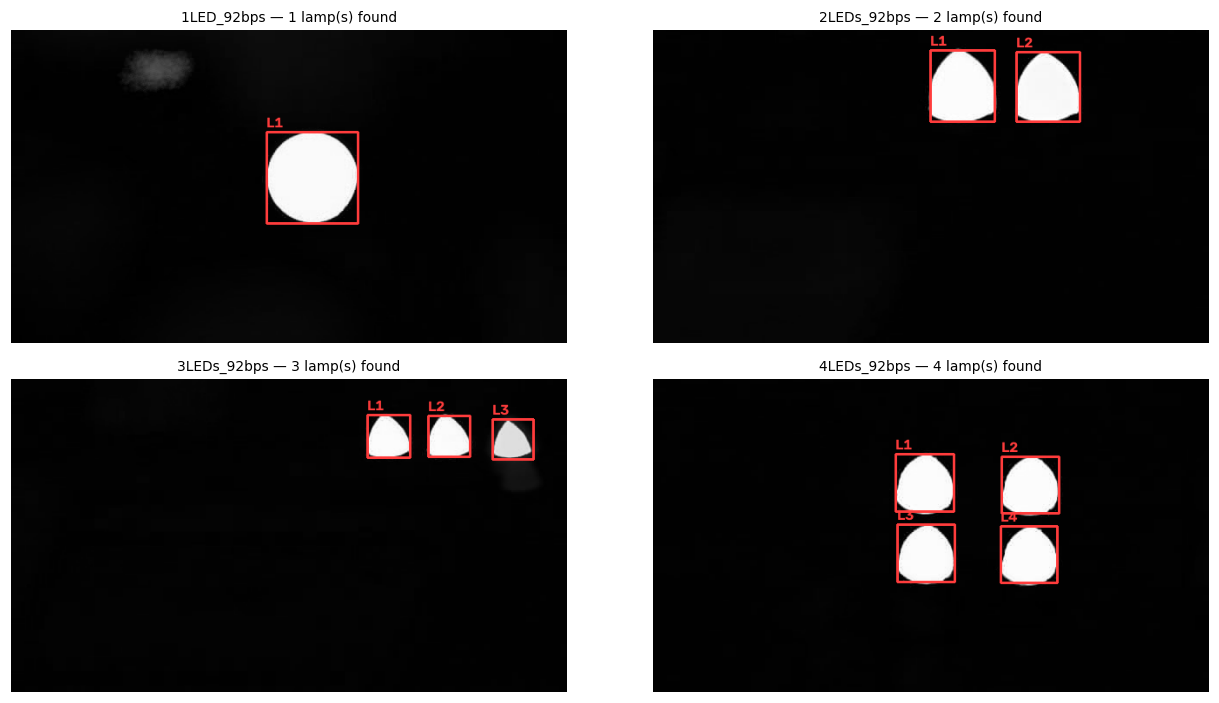

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6.5))
for ax, v in zip(axes.ravel(), videos):
    a,_ = TRIM[v.stem]
    cap = cv2.VideoCapture(str(v)); best=None
    for k in range(150):
        cap.set(cv2.CAP_PROP_POS_FRAMES, a+k*7)
        ok, f = cap.read()
        if not ok: break
        g = cv2.cvtColor(f, cv2.COLOR_BGR2GRAY); sc=int((g>180).sum())
        if best is None or sc>best[0]: best=(sc,g)
    cap.release()
    im = cv2.cvtColor(best[1], cv2.COLOR_GRAY2RGB)
    for L in LAMPS[v.stem]:
        x,y,w,h = L['box']
        cv2.rectangle(im,(x,y),(x+w,y+h),(255,60,60),2)
        cv2.putText(im,f"L{L['id']}",(x,max(14,y-5)),cv2.FONT_HERSHEY_SIMPLEX,.55,(255,60,60),2)
    ax.imshow(im); ax.axis('off')
    ax.set_title(f"{v.stem} — {len(LAMPS[v.stem])} lamp(s) found", fontsize=9)
plt.tight_layout(); plt.show()

### Choosing how to read a bit

2.83 frames per bit means about one frame in three straddles a bit boundary and comes out
part-way between on and off. Which value do we use for the bit?

Four rules, each tested at **every** phase. Lower is better: it is the share of bits landing
too close to the threshold to trust.

demo signal: 4000 frames, range 1..251, threshold 126

rule                                best   worst
nearest frame to centre            0.99%   2.26%
interpolated at centre             5.66%   7.71%
average over the bit              17.26%  19.38%
most confident frame in bit        0.00%   0.00%


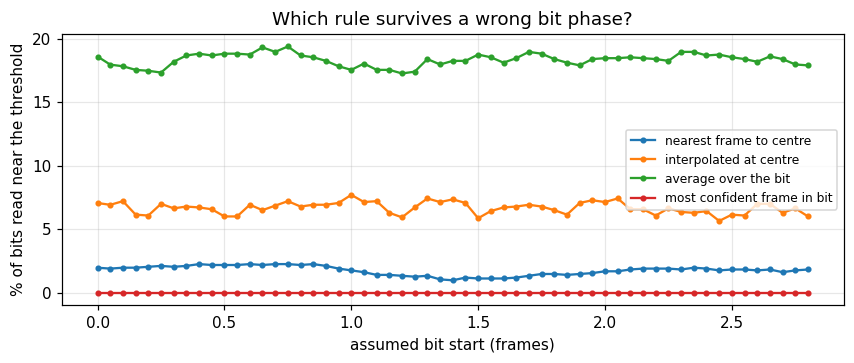

In [9]:
def roi_series(path, box, start, n, frac=0.25):
    x,y,w,h = box
    cap = cv2.VideoCapture(str(path)); cap.set(cv2.CAP_PROP_POS_FRAMES, start)
    out=[]
    for _ in range(n):
        ok, f = cap.read()
        if not ok: break
        p = cv2.cvtColor(f, cv2.COLOR_BGR2GRAY)[y:y+h, x:x+w].reshape(-1)
        out.append(np.sort(p)[-max(1,int(p.size*frac)):].mean())
    cap.release()
    return np.array(out, np.float32)

v0 = videos[0]; a0,_ = TRIM[v0.stem]
demo = roi_series(v0, LAMPS[v0.stem][0]['box'], a0+500, 4000)
thr = (np.percentile(demo,10)+np.percentile(demo,90))/2
print(f"demo signal: {len(demo)} frames, range {demo.min():.0f}..{demo.max():.0f}, "
      f"threshold {thr:.0f}")

def spans(T, ph, n):
    return [(ph+k*T, ph+(k+1)*T) for k in range(int((n-ph-1)//T))]
def r_nearest(s,T,ph):
    return np.array([s[int(round((a+b)/2))] for a,b in spans(T,ph,len(s))
                     if int(round((a+b)/2))<len(s)])
def r_interp(s,T,ph):
    return np.interp(np.array([(a+b)/2 for a,b in spans(T,ph,len(s))]), np.arange(len(s)), s)
def r_average(s,T,ph):
    o=[]
    for a,b in spans(T,ph,len(s)):
        lo,hi=int(np.floor(a)),int(np.ceil(b)); idx=np.arange(lo,min(hi,len(s)))
        wt=np.clip(np.minimum(idx+1,b)-np.maximum(idx,a),0,None)
        o.append((s[idx]*wt).sum()/max(wt.sum(),1e-9))
    return np.array(o)
def r_confident(s,T,ph):
    o=[]
    for a,b in spans(T,ph,len(s)):
        idx=np.arange(int(np.ceil(a)),min(int(np.floor(b))+1,len(s)))
        idx=idx[(idx>=0)&(idx<len(s))]
        o.append(thr if len(idx)==0 else s[idx[np.argmax(np.abs(s[idx]-thr))]])
    return np.array(o)

rules = {'nearest frame to centre': r_nearest, 'interpolated at centre': r_interp,
         'average over the bit': r_average, 'most confident frame in bit': r_confident}
phs = np.arange(0, T92, 0.15 if QUICK else 0.05)
curves = {}
print(f"\n{'rule':32s} {'best':>7s} {'worst':>7s}")
for nm, fn in rules.items():
    sc = [float(np.mean(np.abs(fn(demo,T92,p)-thr) < 25)*100) for p in phs]
    curves[nm] = sc
    print(f"{nm:32s} {min(sc):6.2f}% {max(sc):6.2f}%")

plt.figure(figsize=(8,3.4))
for nm in rules: plt.plot(phs, curves[nm], '-o', ms=3, label=nm)
plt.xlabel('assumed bit start (frames)'); plt.ylabel('% of bits read near the threshold')
plt.title('Which rule survives a wrong bit phase?'); plt.legend(fontsize=8); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

**The winner and its hidden cost.** "Most confident frame in the bit" scores 0.00% at
every phase, because with 2.83 frames per bit at least one frame always falls cleanly
inside the bit.

Averaging over the bit is the textbook matched-filter answer and it is the **worst** here,
because it deliberately mixes in the straddling frames.

But look again at *why* the winner wins: it does not care where the bit starts. That is
exactly what destroys our ability to **find** the boundaries. Section 10 returns to this —
it turned out to be the central problem of the project.

## 4. Day 10 — Explore the signal, and test the stated bit rate

> **Task.** Representative frames; intensity plots; ROI statistics (mean, variance, range, noise); transitions, periods, repeating patterns; ambient, drift, camera and other noise; hypotheses without committing.
> **Delivered.** `week02/day10/Day10_EDA.ipynb` with its inputs regenerated.
> **Status.** The central negative finding: runs of 1 and 4 frames are 22.7% of all runs on 1LED (25–27% on the other lamps) and cannot occur at 92 bps; three rate estimators fail. Four explanations listed, none chosen. Repeating patterns were tested on Day 15 (none).

### Which ROI statistic?

In [10]:
cap = cv2.VideoCapture(str(v0)); cap.set(cv2.CAP_PROP_POS_FRAMES, a0+500)
x,y,w,h = LAMPS[v0.stem][0]['box']
patch=[]
for _ in range(2500):
    ok, f = cap.read()
    if not ok: break
    patch.append(cv2.cvtColor(f, cv2.COLOR_BGR2GRAY)[y:y+h, x:x+w])
cap.release(); patch = np.stack(patch)
flat = lambda p: p.reshape(len(p), -1)
brightest = lambda p, d: np.sort(flat(p),1)[:, -max(1,p[0].size//d):].mean(1)

STATS = {'mean of all pixels': lambda p: flat(p).mean(1),
         'median pixel': lambda p: np.median(flat(p),1),
         'max pixel': lambda p: flat(p).max(1),
         '90th percentile': lambda p: np.percentile(flat(p),90,axis=1),
         'mean of brightest 10%': lambda p: brightest(p,10),
         'mean of brightest 25%': lambda p: brightest(p,4),
         'mean of brightest 50%': lambda p: brightest(p,2),
         'count of pixels > 128': lambda p: (flat(p)>128).sum(1).astype(float)}
print(f"{'statistic':24s} {'gap':>7s} {'noise':>7s} {'gap/noise':>10s}")
for nm, fn in STATS.items():
    vv = fn(patch).astype(float); vv = (vv-vv.min())/(vv.max()-vv.min())*255
    t_ = (np.percentile(vv,10)+np.percentile(vv,90))/2
    on, off = vv[vv>t_+60], vv[vv<t_-60]
    gap = on.mean()-off.mean(); noi = np.sqrt((on.std()**2+off.std()**2)/2)
    print(f"{nm:24s} {gap:7.1f} {noi:7.2f} {gap/noi:10.1f}")
print("\nAll eight work - the signal is far too strong for the choice to matter.")
print("We keep 'mean of brightest 25%': near the top, and unlike max it averages over")
print("many pixels so a single hot pixel cannot swing it.")

statistic                    gap   noise  gap/noise
mean of all pixels         243.0   10.03       24.2
median pixel               248.5    8.16       30.4
max pixel                  248.6    7.85       31.7
90th percentile            248.3    7.16       34.7
mean of brightest 10%      247.6    8.33       29.7
mean of brightest 25%      248.0    7.47       33.2
mean of brightest 50%      247.4    8.61       28.7
count of pixels > 128      248.1    8.28       30.0

All eight work - the signal is far too strong for the choice to matter.
We keep 'mean of brightest 25%': near the top, and unlike max it averages over
many pixels so a single hot pixel cannot swing it.


### The run lengths do not match 92 bps

If one bit lasts 2.826 frames, the lamp can hold a level for about 3 frames (one bit),
6 (two bits) or 9 (three). **Runs of 1, 4 or 7 frames are arithmetically impossible.**

In [11]:
binary = (demo > thr).astype(np.int8)
gaps = np.diff(np.flatnonzero(np.diff(binary)))
print(f"mean run {gaps.mean():.2f} frames = {gaps.mean()/T92:.2f} bits "
      f"(random data would give 2.00 bits)\n")

lo_, hi_ = np.percentile(demo,10), np.percentile(demo,90)
def schmitt(sig, t, band):
    out = np.empty(len(sig), np.int8); st = 1 if sig[0]>t else 0
    for i,vv in enumerate(sig):
        if st==0 and vv>t+band: st=1
        elif st==1 and vv<t-band: st=0
        out[i]=st
    return out
print("Are the odd 1-frame runs just threshold noise? Hysteresis would remove them:")
for frac in (0.0, 0.15, 0.35):
    g = np.diff(np.flatnonzero(np.diff(schmitt(demo, thr, frac*(hi_-lo_)))))
    print(f"   hysteresis {frac:>4.0%} of range: {np.mean(g==1)*100:4.1f}% of runs are 1 frame")
print("\nThey are not noise. Widening the band all the way changes nothing.")

mean run 3.41 frames = 1.21 bits (random data would give 2.00 bits)

Are the odd 1-frame runs just threshold noise? Hysteresis would remove them:
   hysteresis   0% of range:  8.6% of runs are 1 frame
   hysteresis  15% of range:  8.9% of runs are 1 frame
   hysteresis  35% of range:  9.1% of runs are 1 frame

They are not noise. Widening the band all the way changes nothing.


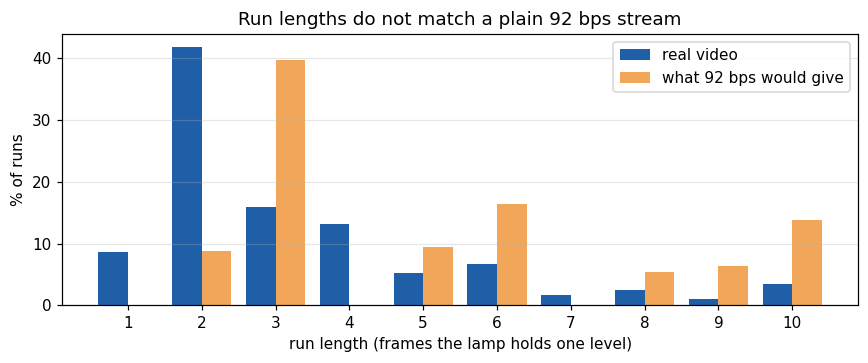

runs of 1 frame : real  8.6%   at 92 bps  0.0%
runs of 4 frames: real 13.2%   at 92 bps  0.0%
Both are impossible at 92 bps. Together they are about a quarter of the data.


In [12]:
rng = np.random.default_rng(1)
def simulate(T, duty=1.0, N=10000):
    """What the camera would record from random bits of period T."""
    nb = int(N/T)+8; bits = rng.integers(0,2,nb).astype(float); e = np.arange(nb+1)*T
    fr = np.empty(N)
    for n in range(N):
        a,b = n, n+duty
        k0,k1 = int(a//T), int(min(b//T, nb-1)); tot=0.
        for k in range(k0,k1+1):
            l,hh = max(a,e[k]), min(b,e[k+1])
            if hh>l: tot += bits[k]*(hh-l)
        fr[n] = tot/duty
    return np.diff(np.flatnonzero(np.diff((fr>0.5).astype(np.int8))))

K=10
obs  = np.bincount(np.clip(gaps,0,K), minlength=K+1)[1:K+1]/len(gaps)
g92  = simulate(T92)
pred = np.bincount(np.clip(g92,0,K), minlength=K+1)[1:K+1]/len(g92)
xs = np.arange(1,K+1); wd=0.4
plt.figure(figsize=(8,3.4))
plt.bar(xs-wd/2, obs*100, wd, label='real video', color='#1f5fa8')
plt.bar(xs+wd/2, pred*100, wd, label='what 92 bps would give', color='#F2A65A')
plt.xlabel('run length (frames the lamp holds one level)'); plt.ylabel('% of runs')
plt.title('Run lengths do not match a plain 92 bps stream')
plt.xticks(xs); plt.legend(); plt.grid(alpha=.3, axis='y'); plt.tight_layout(); plt.show()
print(f"runs of 1 frame : real {obs[0]*100:4.1f}%   at 92 bps {pred[0]*100:4.1f}%")
print(f"runs of 4 frames: real {obs[3]*100:4.1f}%   at 92 bps {pred[3]*100:4.1f}%")
print("Both are impossible at 92 bps. Together they are about a quarter of the data.")

## 5. Day 11 — The extraction pipeline

> **Task.** A deterministic pipeline: frame extraction, ROI, aggregation, signal; smoothing/normalisation only where the EDA justifies it; save signal, frame/timestamp info, ROI and settings.
> **Delivered.** `week02/day11/occ_pipeline.py`, `configs/preprocess_v1.yaml` (reconstructed), `make_frames_csv.py`.
> **Status.** Byte-for-byte reproducible: the ten signals it produces match the frozen Signal V1 on value and file SHA-256. Cleaning off, with the measurement that justifies each switch.

Video in, one brightness value per frame per lamp out. Five stages: read, trim, find lamps,
aggregate, clean. Cleaning is off — section 6 shows why.

The whole thing is deterministic: the same video and settings give byte-identical output.
The only random step is the k-means that groups pixels, and its seed is fixed.

In [13]:
def extract(path, lamps, a, b, frac=0.25):
    cap = cv2.VideoCapture(str(path)); cap.set(cv2.CAP_PROP_POS_FRAMES, a)
    series = [[] for _ in lamps]; n = 0
    while n <= (b-a):
        ok, f = cap.read()
        if not ok: break
        g = cv2.cvtColor(f, cv2.COLOR_BGR2GRAY)
        for i, L in enumerate(lamps):
            x,y,w,h = L['box']
            p = g[y:y+h, x:x+w].reshape(-1)
            series[i].append(np.sort(p)[-max(1,int(p.size*frac)):].mean())
        n += 1
    cap.release()
    return [np.array(s, np.float32) for s in series]

t0 = time.time(); SIG = {}
for v in videos:
    a,b = TRIM[v.stem]
    if QUICK: b = min(b, a + int(FPS*25))          # 25 seconds per video
    for L, s in zip(LAMPS[v.stem], extract(v, LAMPS[v.stem], a, b)):
        SIG[f"{v.stem}-L{L['id']}"] = s
print(f"{len(SIG)} signals extracted in {time.time()-t0:.0f}s"
      + ("  (QUICK: 25 s per video)" if QUICK else ""))
print(f"\n{'signal':18s} {'samples':>8s} {'min':>6s} {'max':>6s} {'fingerprint':>14s}")
for k, s in SIG.items():
    hh = hashlib.sha256(np.ascontiguousarray(s, np.float32).tobytes()).hexdigest()[:12]
    print(f"{k:18s} {len(s):8d} {s.min():6.1f} {s.max():6.1f} {hh:>14s}")

10 signals extracted in 43s

signal              samples    min    max    fingerprint
1LED_92bps-L1         27856    1.0  252.1   325e405405e4
2LEDs_92bps-L1        17195    1.0  253.2   a00e2ff3e552
2LEDs_92bps-L2        17195    1.0  253.3   d637bcedfeaa
3LEDs_92bps-L1        11466    1.3  252.7   ab44db3b24ec
3LEDs_92bps-L2        11466    1.0  252.9   bd96eb79dbc7
3LEDs_92bps-L3        11466    1.7  236.0   a0834b6280c0
4LEDs_92bps-L1         8609    1.0  253.1   1ce48e742fdc
4LEDs_92bps-L2         8609    1.0  253.1   02f0603e51f0
4LEDs_92bps-L3         8609    1.0  252.7   9d3aa2d251c1
4LEDs_92bps-L4         8609    1.0  253.1   724655986359


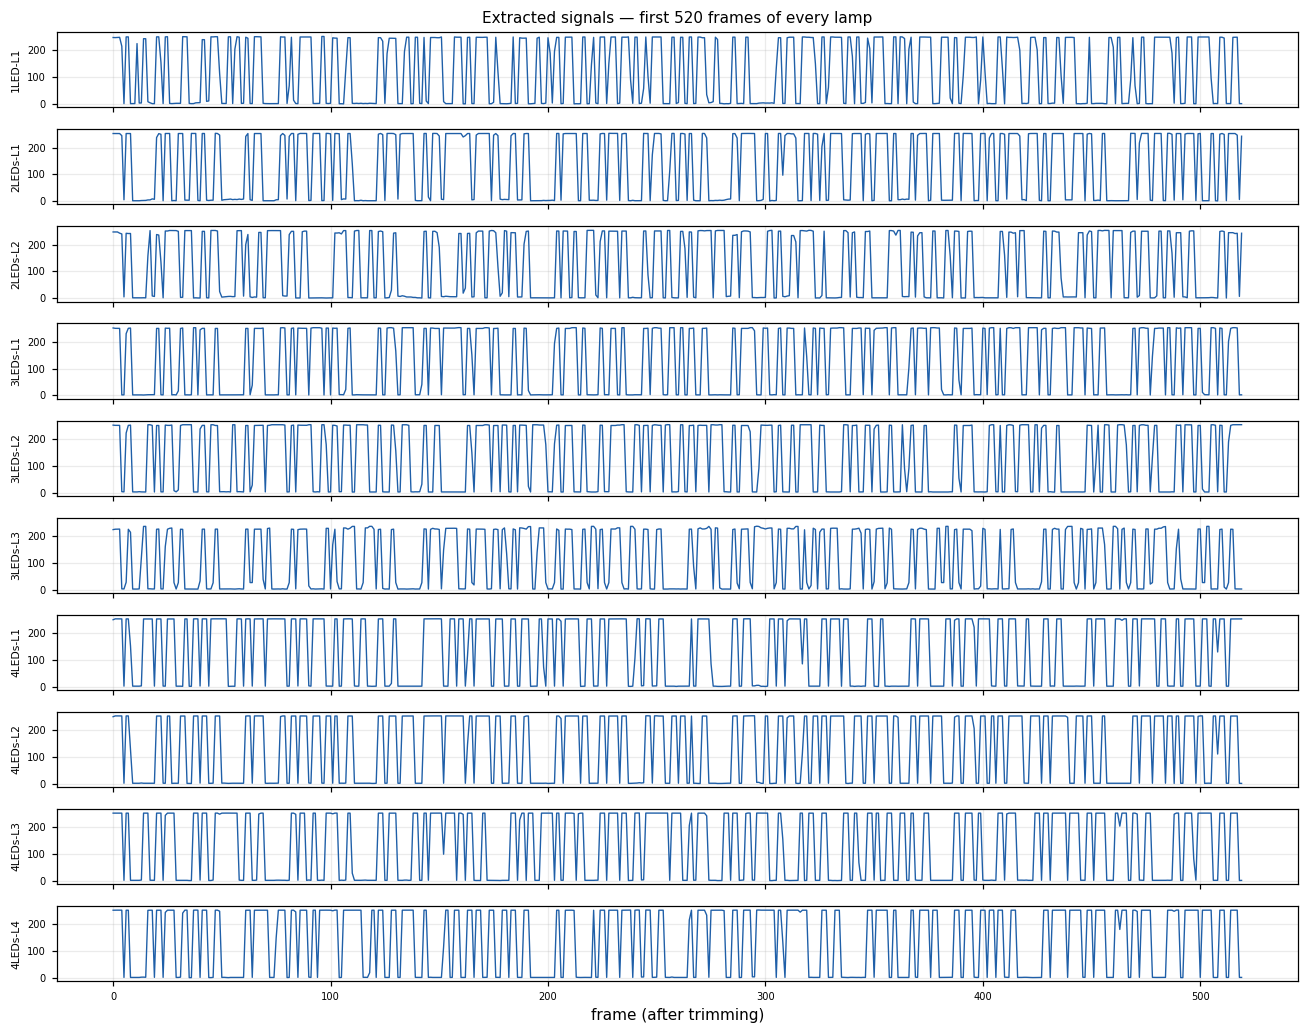

In [14]:
n = len(SIG)
fig, axes = plt.subplots(n, 1, figsize=(12, 0.95*n), sharex=True)
axes = np.atleast_1d(axes)
for ax, (k, s) in zip(axes, SIG.items()):
    ax.plot(s[:520], lw=.9, color='#1f5fa8')
    ax.set_ylabel(k.replace('_92bps',''), fontsize=7); ax.set_ylim(-12,268)
    ax.grid(alpha=.25); ax.tick_params(labelsize=6.5)
axes[0].set_title('Extracted signals — first 520 frames of every lamp', fontsize=10)
axes[-1].set_xlabel('frame (after trimming)')
plt.tight_layout(); plt.show()

## 6. Day 12 — Does any cleaning step help?

> **Task.** Present ROI, pipeline, signal and plots; defend smoothing, normalisation, aggregation; review quality; freeze Signal V1.
> **Delivered.** `week02/day12/`: ablation, `freeze_signal.py`, `signal_v1/` (frozen, two fingerprints per file, committed, `frames.csv` per video).
> **Status.** Every cleaning option lowers the on/off separation; smoothing deletes real transitions. Signal V1 frozen; all seven ablation rows reproduce exactly.

The original plan had detrending and rolling normalisation at the centre of the method.
This measures them instead of assuming them.

In [15]:
def moving(sig, w):
    w = int(w) | 1
    pad = np.pad(sig, (w//2, w//2), mode='edge')
    return np.convolve(pad, np.ones(w)/w, mode='valid')

def clean(sig, detrend=0, normalise=0, smooth=0):
    out = sig.astype(np.float32)
    if detrend > 1:
        base = moving(out, detrend); out = out - base + float(base.mean())
    if normalise > 1:
        mu = moving(out, normalise)
        sd = np.sqrt(moving((out-mu)**2, normalise)) + 1e-6
        out = (out-mu)/sd
    if smooth > 1:
        out = moving(out, smooth)
    return out.astype(np.float32)

def quality(sig):
    t_ = (np.percentile(sig,10)+np.percentile(sig,90))/2
    span = np.ptp(sig)
    on, off = sig[sig>t_+0.25*span], sig[sig<t_-0.25*span]
    gap = on.mean()-off.mean(); noi = np.sqrt((on.std()**2+off.std()**2)/2)
    tr = int(np.sum(np.diff((sig>t_).astype(np.int8))!=0))
    return gap/max(noi,1e-9), tr

VAR = {'baseline (all off)': dict(),
       'smooth window 3': dict(smooth=3),
       'smooth window 5': dict(smooth=5),
       'detrend 1 s': dict(detrend=261),
       'normalise 1 s': dict(normalise=261),
       'all three': dict(detrend=261, normalise=261, smooth=3)}
print(f"{'configuration':22s} {'gap/noise':>10s} {'transitions kept':>18s}")
base_tr = None
for nm, kw in VAR.items():
    snrs, trs = [], []
    for s in SIG.values():
        q, tr = quality(clean(s, **kw)); snrs.append(q); trs.append(tr)
    if base_tr is None: base_tr = np.mean(trs)
    print(f"{nm:22s} {np.mean(snrs):10.1f} {np.mean(trs)/base_tr*100:17.1f}%")
print("\nEvery option lowers the separation, and none improves anything.")
print("Smoothing also deletes real level changes: one bit lasts under 3 frames, so a")
print("3-frame window is wider than a bit and averages each one with its neighbours.")

configuration           gap/noise   transitions kept
baseline (all off)           57.9             100.0%
smooth window 3              31.9              73.1%
smooth window 5              11.4              43.3%
detrend 1 s                  25.1             100.0%
normalise 1 s                24.8             100.0%
all three                    21.4              73.1%

Every option lowers the separation, and none improves anything.
Smoothing also deletes real level changes: one bit lasts under 3 frames, so a
3-frame window is wider than a bit and averages each one with its neighbours.


## 7. Day 13 — Try to recover the symbol clock

> **Task.** Estimate the symbol clock from transitions, periodicity, repeated patterns, spacing; candidate boundaries; markers over the signal; multiple hypotheses; do not commit prematurely.
> **Delivered.** `week02/day13/Day13_Synchronisation.ipynb`, `candidate_timing.json` (labelled *assumed*), hypotheses H1–H4.
> **Status.** **No clock at any rate.** Level changes fit a 92 bps grid 0.3% better than random times; the best-anywhere bump (173 bps) is the 1.5-frame arithmetic artefact. Candidate timing is declared an assumption.

The central question. If a 92 bps clock exists, the level changes should sit on its grid.

Two reference points make the numbers readable:

- **No structure at all:** changes scattered anywhere average a quarter of the period away
  from the nearest boundary.
- **A real clock:** changes timed to the nearest frame would average about a quarter of a
  frame away — roughly 50% better.

8300 level changes in 27856 frames



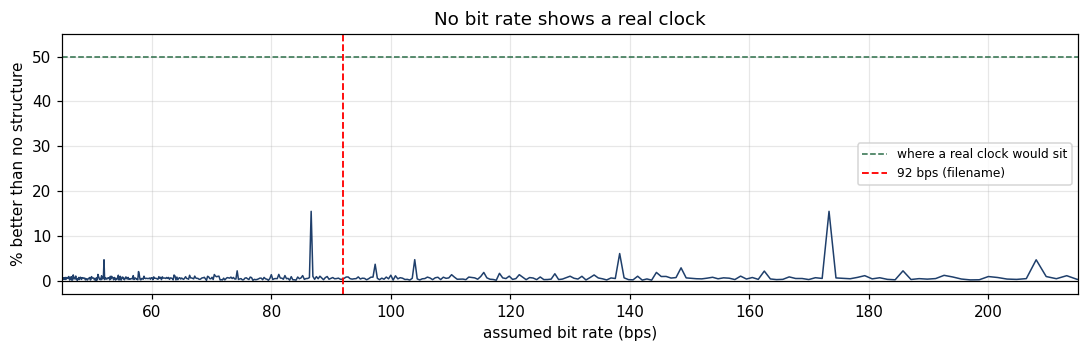

at 92 bps     : 0.3% better than no structure
best anywhere : 15.5% at 173.3 bps

The bump near 173 bps sits at exactly 1.5 frames, where every second boundary
lands on a whole frame number. That is arithmetic, not a clock.


In [16]:
s = SIG[list(SIG)[0]]
th = (np.percentile(s,10)+np.percentile(s,90))/2
edges = np.flatnonzero(np.diff((s>th).astype(np.int8)))+1
print(f"{len(edges)} level changes in {len(s)} frames\n")

def grid_score(ed, T, steps=30):
    best = 1e9
    for ph in np.linspace(0, T, steps, endpoint=False):
        r = (ed-ph)/T
        best = min(best, float(np.mean(np.abs(r-np.round(r)))*T))
    return best

Tg = np.arange(1.2, 6.0, 0.02 if QUICK else 0.01)
obs_g = np.array([grid_score(edges, T) for T in Tg])
better = ((Tg/4) - obs_g)/(Tg/4)*100

plt.figure(figsize=(10,3.3))
plt.plot(FPS/Tg, better, lw=1, color='#1f3f6b')
plt.axhline(0, color='k', lw=.8)
plt.axhline(50, color='#2C6E49', ls='--', lw=1, label='where a real clock would sit')
plt.axvline(BPS, color='r', ls='--', lw=1.2, label='92 bps (filename)')
plt.xlabel('assumed bit rate (bps)'); plt.ylabel('% better than no structure')
plt.title('No bit rate shows a real clock'); plt.xlim(45,215); plt.ylim(-3,55)
plt.legend(fontsize=8); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

i92 = int(np.argmin(np.abs(FPS/Tg-BPS)))
print(f"at 92 bps     : {better[i92]:.1f}% better than no structure")
print(f"best anywhere : {better.max():.1f}% at {FPS/Tg[np.argmax(better)]:.1f} bps")
print("\nThe bump near 173 bps sits at exactly 1.5 frames, where every second boundary")
print("lands on a whole frame number. That is arithmetic, not a clock.")

In [17]:
rng2 = np.random.default_rng(0)
def dists(times, T, ph):
    r = (times-ph)/T
    return np.abs(r-np.round(r))*T
ph_best = min(np.linspace(0,T92,120,endpoint=False), key=lambda p: dists(edges,T92,p).mean())
d_obs  = dists(edges, T92, ph_best)
d_rand = dists(rng2.uniform(0,len(s),len(edges)), T92, ph_best)
print("distance from the nearest 92 bps bit boundary:")
print(f"   observed changes : mean {d_obs.mean():.3f} frames, "
      f"{np.mean(d_obs>0.5)*100:.1f}% further than half a frame")
print(f"   random times     : mean {d_rand.mean():.3f} frames, "
      f"{np.mean(d_rand>0.5)*100:.1f}% further than half a frame")
print("\nIdentical. A real edge can only be out by half a frame - that is all the")
print("rounding allows. There is no 92 bps clock in this signal.")

distance from the nearest 92 bps bit boundary:
   observed changes : mean 0.703 frames, 64.0% further than half a frame
   random times     : mean 0.705 frames, 64.3% further than half a frame

Identical. A real edge can only be out by half a frame - that is all the
rounding allows. There is no 92 bps clock in this signal.


## 8. Day 14 — The beat between the bit grid and the frame grid

> **Task.** Peer review of signal and synchronisation findings; difficult segments; record a peer insight and a testable hypothesis; the Week-2 package.
> **Delivered.** `week02/day14/`: `WEEK2_PACKAGE.MD`, `SYNC_HYPOTHESES.MD` (H1–H5), `beat_analysis.py`. The peer record itself was never filled in (`PEER_REVIEW.MD` template).
> **Status.** E8/E9 verified: shared 1-frame glitches coincide 2.3–3.9× chance and repeat every ~20–21 frames. H5 (a clock that beats against the frame grid) is the one lead; it points to ~82, ~91, ~124 or ~136 bps, not 92.0.

The most promising lead in the project, found late.

The odd 1-frame runs are not noise (section 4). Do they happen at the **same moments** on
different lamps? The lamps carry different data, so if these coincide, something shared is
causing them. The transmitter clock is the obvious shared thing; a shared preamble or
framing (Day 7 §4) would also do it and has not been ruled out *(audit wording)*.

In [18]:
def short_run_starts(sig):
    t_ = (np.percentile(sig,10)+np.percentile(sig,90))/2
    e = np.flatnonzero(np.diff((sig>t_).astype(np.int8)))+1
    r = np.diff(e)
    return e[:-1][r==1], len(sig)

for v in videos:
    keys = [k for k in SIG if k.startswith(v.stem)]
    if len(keys) < 2: continue
    print(f"{v.stem}:")
    for i in range(len(keys)):
        for j in range(i+1, len(keys)):
            si, n = short_run_starts(SIG[keys[i]]); sj, _ = short_run_starts(SIG[keys[j]])
            a_ = np.zeros(n, bool); a_[si[si<n]] = True
            b_ = np.zeros(n, bool); b_[sj[sj<n]] = True
            aw = a_ | np.roll(a_,1) | np.roll(a_,-1)
            hit = int(np.sum(aw & b_)); exp = np.sum(aw)/n*np.sum(b_)
            print(f"   lamp{i+1} vs lamp{j+1}: {hit:5d} coincide, {exp:6.1f} expected "
                  f"by chance -> {hit/max(exp,1e-9):.2f}x")
print("\nThey coincide far more than chance. Different data, shared timing.")

2LEDs_92bps:
   lamp1 vs lamp2:   328 coincide,  105.0 expected by chance -> 3.12x
3LEDs_92bps:
   lamp1 vs lamp2:   218 coincide,   56.9 expected by chance -> 3.83x
   lamp1 vs lamp3:   137 coincide,   39.6 expected by chance -> 3.46x
   lamp2 vs lamp3:   135 coincide,   39.9 expected by chance -> 3.38x
4LEDs_92bps:
   lamp1 vs lamp2:   210 coincide,   62.2 expected by chance -> 3.38x
   lamp1 vs lamp3:   163 coincide,   63.2 expected by chance -> 2.58x
   lamp1 vs lamp4:   157 coincide,   62.5 expected by chance -> 2.51x
   lamp2 vs lamp3:   166 coincide,   65.2 expected by chance -> 2.55x
   lamp2 vs lamp4:   147 coincide,   64.4 expected by chance -> 2.28x
   lamp3 vs lamp4:   219 coincide,   65.5 expected by chance -> 3.34x

They coincide far more than chance. Different data, shared timing.


strongest repeats in the shared-glitch pattern (lag frames, strength):
   [(21, 0.176), (81, 0.149), (41, 0.061), (61, 0.047), (45, 0.043)]


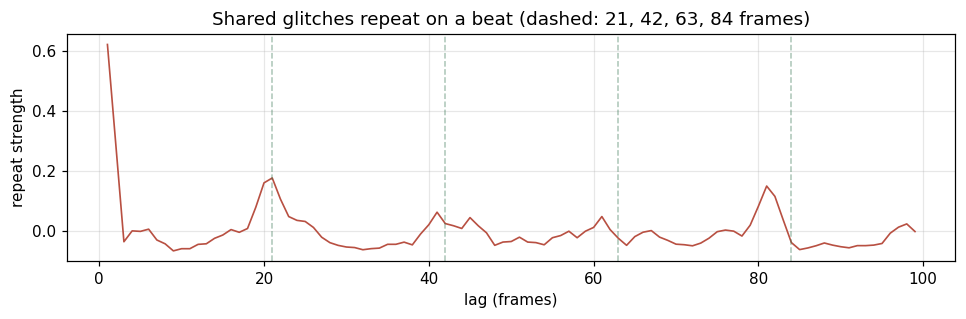


Two grids drifting past each other realign every
T / |T - nearest whole number| frames. For a 21-frame beat:
   period 1.905 frames = 136.48 bps  ->  beat  20.1 frames
   period 1.910 frames = 136.13 bps  ->  beat  21.2 frames
   period 2.100 frames = 123.81 bps  ->  beat  21.0 frames
   period 2.105 frames = 123.52 bps  ->  beat  20.0 frames
   period 2.855 frames =  91.07 bps  ->  beat  19.7 frames
   period 2.860 frames =  90.91 bps  ->  beat  20.4 frames
   period 2.865 frames =  90.75 bps  ->  beat  21.2 frames


In [19]:
keys = [k for k in SIG if k.startswith(videos[-1].stem)]
if len(keys) >= 3:
    n = min(len(SIG[k]) for k in keys); votes = np.zeros(n)
    for k in keys:
        sh, _ = short_run_starts(SIG[k])
        vv = np.zeros(n); vv[sh[sh<n]] = 1
        votes += np.convolve(vv, np.ones(3), mode='same') > 0
    tr = (votes >= 3).astype(float); xx = tr - tr.mean()
    ac = np.correlate(xx, xx, 'full')[n-1:]; ac /= ac[0]
    pk = sorted([(ac[k_], k_) for k_ in range(4, min(90, n-2))
                 if ac[k_]>ac[k_-1] and ac[k_]>=ac[k_+1]], reverse=True)[:5]
    print("strongest repeats in the shared-glitch pattern (lag frames, strength):")
    print("  ", [(k_, round(float(vv_),3)) for vv_, k_ in pk])

    plt.figure(figsize=(9,3))
    plt.plot(np.arange(1,100), ac[1:100], lw=1.1, color='#B85042')
    for k_ in (21,42,63,84): plt.axvline(k_, color='#2C6E49', alpha=.4, ls='--', lw=1)
    plt.xlabel('lag (frames)'); plt.ylabel('repeat strength')
    plt.title('Shared glitches repeat on a beat (dashed: 21, 42, 63, 84 frames)')
    plt.grid(alpha=.3); plt.tight_layout(); plt.show()

    print("\nTwo grids drifting past each other realign every")
    print("T / |T - nearest whole number| frames. For a 21-frame beat:")
    for T in np.arange(1.8, 3.0, 0.005):
        d = abs(T-round(T))
        if d > 1e-6 and 19.5 < T/d < 21.5:
            print(f"   period {T:.3f} frames = {FPS/T:6.2f} bps  ->  beat {T/d:5.1f} frames")

**What this means.** A ~20–21-frame beat is consistent with four bit rates in the plausible
range: about 136, about 124, **about 91 bps** — within 1.2% of the filename's 92 — and about
82 on the far side of the 3-frame pole (the repeat lags 21/41/61/81 are spaced 20, so the beat
is nearer 20.2 than 21; the candidates move by a rounding). The filename's 2.826 frames would
give a 16-frame beat, which is not observed.

It does not prove 92 bps; the candidates fit equally well. But it is the first evidence
pointing back toward something near the stated rate, and it argues against the idea that
the light simply switches faster than the camera can follow — aliasing would not produce a
stable, repeatable beat.

## 9. Day 15 — Threshold decoder and consistency checks

> **Task.** Fixed and adaptive threshold decoders; preliminary bits from Signal V1; consistency and error indicators; visualise decisions over the signal; document parameters; mentor direction.
> **Delivered.** `week03/day15/decoder.py`, `decode_report.json`, `fig_decode.png`, `fig_decisions.png`, `plot_decisions.py`.
> **Status.** 46,372 preliminary bits at the assumed rate. The phase estimate is blind: the confidence score is identical at every phase while a third of the bits change. Days 15–16 predate the DEV/TEST split; nothing was tuned on them.

Two decision rules, fixed and adaptive, both using the sampling rule chosen in section 3.

Reminder: **no ground truth was supplied.** Nothing below measures whether a bit is
correct.

In [20]:
def decode_fast(s, thr_arr, T, phase, max_off=4):
    """One bit per period; within each bit take the frame furthest from the
    threshold. Vectorised - the plain loop version took minutes per signal."""
    nb = int((len(s)-phase-1)//T)
    if nb <= 0: return np.zeros(0, np.int8), np.zeros(0, np.float32)
    starts = phase + np.arange(nb)*T
    lo = np.ceil(starts).astype(int); hi = np.floor(starts+T).astype(int)
    d_best = np.zeros(nb); a_best = np.full(nb, -1.0)
    for j in range(max_off):
        idx = lo + j
        ok = (idx <= hi) & (idx >= 0) & (idx < len(s))
        cl = np.clip(idx, 0, len(s)-1)
        d = np.where(ok, s[cl] - thr_arr[cl], 0.0)
        take = ok & (np.abs(d) > a_best)
        d_best = np.where(take, d, d_best)
        a_best = np.where(take, np.abs(d), a_best)
    return (d_best > 0).astype(np.int8), np.abs(d_best).astype(np.float32)

def fixed_thr(s):
    return np.full(len(s), (np.percentile(s,10)+np.percentile(s,90))/2, np.float32)

def adaptive_thr(s, w=2600):
    w = int(min(w, max(51, len(s)//4))); step = max(1, w//8)
    idx = np.arange(0, len(s), step); pad = np.pad(s, (w//2, w//2), mode='edge')
    lo = np.interp(np.arange(len(s)), idx, [np.percentile(pad[i:i+w],10) for i in idx])
    hi = np.interp(np.arange(len(s)), idx, [np.percentile(pad[i:i+w],90) for i in idx])
    return ((lo+hi)/2).astype(np.float32)

print(f"{'signal':18s} {'bits':>6s} {'ones':>7s} {'flips':>7s} {'fixed vs adaptive':>18s}")
BITS = {}
for k, s in SIG.items():
    bf, mf = decode_fast(s, fixed_thr(s), T92, 0.0)
    ba, _  = decode_fast(s, adaptive_thr(s), T92, 0.0)
    n = min(len(bf), len(ba)); BITS[k] = bf
    print(f"{k:18s} {len(bf):6d} {bf.mean()*100:6.1f}% "
          f"{np.mean(np.diff(bf)!=0)*100:6.1f}% {np.mean(bf[:n]==ba[:n])*100:17.2f}%")
print("\nThe threshold choice barely matters on a signal this clean.")

signal               bits    ones   flips  fixed vs adaptive
1LED_92bps-L1        9856   45.2%   48.4%             98.86%
2LEDs_92bps-L1       6084   60.0%   43.3%             99.39%
2LEDs_92bps-L2       6084   40.8%   44.8%             99.59%
3LEDs_92bps-L1       4056   39.2%   44.3%             99.11%
3LEDs_92bps-L2       4056   40.0%   44.1%             99.11%
3LEDs_92bps-L3       4056   41.6%   48.1%             98.99%
4LEDs_92bps-L1       3045   48.2%   46.6%             98.16%
4LEDs_92bps-L2       3045   47.7%   46.3%             97.08%
4LEDs_92bps-L3       3045   54.4%   46.2%             99.01%
4LEDs_92bps-L4       3045   51.6%   48.1%             97.80%

The threshold choice barely matters on a signal this clean.


In [21]:
# The problem: the score used to pick the phase does not depend on the phase.
s = SIG[list(SIG)[0]]; tf = fixed_thr(s)
b0, _ = decode_fast(s, tf, T92, 0.0)
print(f"{'phase shift':>12s} {'bits unchanged':>16s} {'confidence score':>18s}")
for frac in (0.0, 0.1, 0.2, 0.3, 0.5, 0.7):
    b, m = decode_fast(s, tf, T92, frac*T92)
    n = min(len(b0), len(b))
    print(f"{frac:11.1f}b {np.mean(b0[:n]==b[:n])*100:15.2f}% {np.mean(m):17.1f}")
print("\nA third of the bits change while the score does not move at all. So the phase")
print("is chosen by floating-point noise, and the decoder reports full confidence")
print("whichever phase it happens to land on.")

 phase shift   bits unchanged   confidence score
        0.0b          100.00%             123.5
        0.1b           92.53%             123.5
        0.2b           86.11%             123.5
        0.3b           79.20%             123.5
        0.5b           67.73%             123.5
        0.7b           59.05%             123.5

A third of the bits change while the score does not move at all. So the phase
is chosen by floating-point noise, and the decoder reports full confidence
whichever phase it happens to land on.


**Where this came from.** Section 3 chose the sampling rule *because* it was blind to
the phase, and that looked like robustness. It is — for reading a bit once you know the
boundaries. But it removed exactly the signal a phase estimate needs. The Day 09 slide said
"it does not care where we think the bit starts". That sentence was the warning.

## 10. Day 16 — Which bits survive an unknown phase

> **Task.** Improve timing and transition handling; test boundary estimation, transition-aware decoding, adaptive threshold, local normalisation; compare across videos; log parameters.
> **Delivered.** `week03/day16/decoder_v2.py`, `report.json`, parameter log.
> **Status.** Sub-frame timing failed (no intermediate frames to interpolate). v2 declares the phase a convention and outputs a per-bit safe mask: ~44% of every stream. The timing improvements that worked came on Days 17 and 19 (Part III).

If the phase cannot be found, ask a different question: which bits do not depend on it?

In [22]:
NPH = 8 if QUICK else 12
print(f"decoding at {NPH} phases and comparing\n")
print(f"{'signal':18s} {'bits':>7s} {'phase-independent':>19s}")
SAFE = {}
for k, s in SIG.items():
    tf = fixed_thr(s)
    stack = [decode_fast(s, tf, T92, ph)[0]
             for ph in np.linspace(0, T92, NPH, endpoint=False)]
    n = min(len(b) for b in stack)
    M = np.stack([b[:n] for b in stack]); votes = M.mean(axis=0)
    safe = (votes==0) | (votes==1); SAFE[k] = safe
    print(f"{k:18s} {n:7d} {safe.mean()*100:18.1f}%")
print(f"\nmedian: {np.median([v.mean()*100 for v in SAFE.values()]):.1f}%")
print("Under half of every stream is decided. The rest is unknowable until the phase")
print("is known - and section 7 showed the phase cannot be recovered from this data.")

decoding at 12 phases and comparing

signal                bits   phase-independent
1LED_92bps-L1         9855               40.8%
2LEDs_92bps-L1        6083               47.5%
2LEDs_92bps-L2        6083               43.2%
3LEDs_92bps-L1        4055               43.7%
3LEDs_92bps-L2        4055               43.7%
3LEDs_92bps-L3        4055               40.8%
4LEDs_92bps-L1        3044               45.8%
4LEDs_92bps-L2        3044               45.5%
4LEDs_92bps-L3        3044               46.8%
4LEDs_92bps-L4        3044               44.8%

median: 44.3%
Under half of every stream is decided. The rest is unknowable until the phase
is known - and section 7 showed the phase cannot be recovered from this data.


In [23]:
k0 = list(SIG)[0]; b = BITS[k0]; safe = SAFE[k0]
n = min(len(b), len(safe)); b, safe = b[:n], safe[:n]
runlen = np.empty(n, int); i = 0
while i < n:
    j = i
    while j+1 < n and b[j+1]==b[i]: j += 1
    runlen[i:j+1] = j-i+1; i = j+1
print(f"{'bit sits in a run of':>22s} {'count':>8s} {'phase-independent':>19s}")
for L in (1,2,3,4):
    sel = runlen==L
    if sel.sum() > 20:
        print(f"{L:22d} {sel.sum():8d} {safe[sel].mean()*100:18.1f}%")
print("\nExactly as expected: a bit surrounded by identical neighbours survives a")
print("shifted window. An isolated bit does not.")

  bit sits in a run of    count   phase-independent
                     1     2541                7.8%
                     2     2120               42.4%
                     3     1479               47.4%
                     4     1184               57.9%

Exactly as expected: a bit surrounded by identical neighbours survives a
shifted window. An isolated bit does not.


In [24]:
def corr(a, b):
    n = min(len(a), len(b))
    return float(np.mean((a[:n].astype(float)*2-1) * (b[:n].astype(float)*2-1)))
same, diff = [], []
for a, b in itertools.combinations(list(BITS), 2):
    c = corr(BITS[a], BITS[b])
    (same if a.split('-L')[0]==b.split('-L')[0] else diff).append(c)
rng3 = np.random.default_rng(0)
sh = [corr(rng3.permutation(BITS[a]), BITS[b])
      for a, b in itertools.combinations(list(BITS), 2)]
print(f"lamp pairs in the SAME video   : mean {np.mean(same):+.3f}  (n={len(same)}, "
      f"range {min(same):+.3f} .. {max(same):+.3f})")
print(f"lamp pairs in DIFFERENT videos : mean {np.mean(diff):+.3f}  (n={len(diff)}, "
      f"range {min(diff):+.3f} .. {max(diff):+.3f})")
print(f"one stream shuffled (control)  : mean {np.mean(sh):+.3f}")
print("(all at lag 0)")
print("\nOn average, lamps within one recording share a component while carrying different")
print("messages. It is not uniform: the 2LEDs pair shows almost none of it, the 3LEDs")
print("pairs the most (audit). The leading explanation is the shared clock section 8")
print("found in the glitch timing; a shared preamble would look the same and is not")
print("ruled out. Either way, treating the lamps as independent streams would be wrong.")
print("\nThe across-video figure is much smaller but not zero. Separate recordings")
print("cannot share a message, so that residue comes from our own decoding: every")
print("stream is sampled on the same assumed period and the same phase convention.")
print("It is larger in QUICK mode, where the shorter signals give it less to average")
print("away (full-length runs give about +0.06 against +0.26 within a video).")

lamp pairs in the SAME video   : mean +0.258  (n=10, range +0.011 .. +0.379)
lamp pairs in DIFFERENT videos : mean +0.057  (n=35, range -0.026 .. +0.256)
one stream shuffled (control)  : mean +0.004
(all at lag 0)

On average, lamps within one recording share a component while carrying different
messages. It is not uniform: the 2LEDs pair shows almost none of it, the 3LEDs
pairs the most (audit). The leading explanation is the shared clock section 8
found in the glitch timing; a shared preamble would look the same and is not
ruled out. Either way, treating the lamps as independent streams would be wrong.

The across-video figure is much smaller but not zero. Separate recordings
cannot share a message, so that residue comes from our own decoding: every
stream is sampled on the same assumed period and the same phase convention.
It is larger in QUICK mode, where the shorter signals give it less to average
away (full-length runs give about +0.06 against +0.26 within a video).


# Part III — Days 17 to 21: decoding experiments under strict discipline

From here on the notebook reuses the committed Week-3 modules (`week03/day17/occlib.py` and
the per-day scripts) rather than re-implementing them, so the numbers here are the numbers in
the day reports. Three rules hold throughout:

* **Split.** Each real signal is cut at 30%: the first part is DEV (tuning, indicators), the
  last 70% is TEST, opened once, in section 15. Synthetic seeds are disjoint per role
  (train 0–3, test 10–13 / 20–23, validation 30–33, final test 50–53).
* **Labels.** None exist for the videos; "training labels" are synthetic true bits or the
  threshold decoder's own phase-independent decisions, and the two are never mixed.
* **Metrics.** BER only on synthetic signals. On real signals: phase-independent share,
  phase stability, threshold tolerance, agreement between decoders — none of them correctness.

In [25]:
import sys
REPO = Path.cwd()
for d in ("day17", "day18", "day19", "day20", "day21"):
    sys.path.insert(0, str(REPO / "week03" / d))
import occlib as L
from occlib import T92, decode, fixed_thr, adaptive_thr, phase_ensemble, indicators, agreement, ber, random_bits, synth, split
SV1 = L.load_signal_v1()
DEV  = {k: split(v, "dev")  for k, v in SV1.items()}
TEST = {k: split(v, "test") for k, v in SV1.items()}
print(f"Signal V1: {len(SV1)} lamps, {sum(len(v) for v in SV1.values()):,} samples")
print(f"DEV {sum(len(v) for v in DEV.values()):,} samples | TEST {sum(len(v) for v in TEST.values()):,} samples (not read until section 15)")
# the shared library's own self-check: reproduces Day 16's 40.82% safe bits on 1LED
_, _, _safe = phase_ensemble(SV1['1LED_92bps/lamp1'], fixed_thr(SV1['1LED_92bps/lamp1']))
assert abs(_safe.mean()*100 - 40.82) < 0.05
print("occlib reproduces Day 16 (1LED safe bits 40.82%)")

Signal V1: 10 lamps, 131,080 samples
DEV 39,317 samples | TEST 91,763 samples (not read until section 15)
occlib reproduces Day 16 (1LED safe bits 40.82%)


## 11. Day 17 — ML-assisted symbol decision

> **Task.** Where labels or training segments permit, a simple, interpretable symbol
> classifier; features and classes defined; compared with the threshold baseline on the same
> criteria; no message content as labels; train/validation/test separated; model and logic
> saved; where it improves and where it fails.
> **Delivered.** `week03/day17/`: `occlib.py`, `ml_decoder.py`, `ml_report.json`,
> `ml_model_synthetic.json`, `ml_model_real_pseudo.json`, `fig_ml.png`.

**Features** per bit window (phase-0 convention): the five frames from one before the window
start to three after, as `(value − threshold) / range`, plus the fractional position of the
window start inside a frame — the one piece of grid information the most-confident-frame rule
throws away. **Classes:** 0 / 1. **Model:** logistic regression (`C = 1`), the plan's first
choice; nothing bigger was tried because §3 below shows why it would not help.

**A. Synthetic, true labels.** `occlib.synth` builds the *assumed* model: a clean 92 bps
clock, contrast 245, exposure 0.3 frame (Day 13's inference), noise as measured. Threshold
and classifier are compared at the true phase (decision quality alone) and at phase 0 (the
real situation).

In [26]:
from ml_decoder import synthetic_experiment, real_experiment
model_syn, syn_rows, syn_meta = synthetic_experiment()
print(f"trained on {syn_meta['n_train_bits']:,} synthetic bits in {syn_meta['train_time_s']} s\n")
print(f"{'noise':>6s} {'expo':>5s} | {'thr@true':>9s} {'thr+m.3':>8s} {'ml@true':>8s} | {'thr@ph0':>8s} {'thr+m.3':>8s} {'ml@ph0':>7s}   (BER %)")
for r in syn_rows:
    print(f"{r['noise']:6d} {r['exposure']:5.1f} | {r['ber_threshold_true_phase']:9.3f} "
          f"{r['ber_threshold_margin03_true_phase']:8.3f} {r['ber_ml_true_phase']:8.3f} | "
          f"{r['ber_threshold_phase0']:8.2f} {r['ber_threshold_margin03_phase0']:8.2f} {r['ber_ml_phase0']:7.2f}")
print("\nReal data sits at noise 6-11, exposure ~0.3: the first row.")

trained on 95,968 synthetic bits in 0.081 s

 noise  expo |  thr@true  thr+m.3  ml@true |  thr@ph0  thr+m.3  ml@ph0   (BER %)
     8   0.3 |     0.025    0.000    0.000 |    18.82    17.99   13.29
     8   1.0 |     0.567    0.000    0.000 |     0.23     0.20    0.25
    40   0.3 |     0.625    0.000    0.000 |    17.11    16.18   12.04
    40   1.0 |     2.434    0.150    0.000 |     7.45     6.88    4.49
    80   0.3 |     2.292    1.100    1.225 |    12.02    11.71   11.36
    80   1.0 |     5.385    2.434    1.350 |     8.45     8.69   11.07
   110   0.3 |     5.310    4.435    4.518 |    13.16    12.18   11.05
   110   1.0 |     9.153    6.802    5.152 |    16.19    16.19   14.27

Real data sits at noise 6-11, exposure ~0.3: the first row.


**Three things this says.** (1) With the phase known, the classifier beats the threshold —
but most of the threshold's errors were a bug: the Day 15/16 bit window runs to
`floor(start + T)`, and with a short exposure that last frame exposes inside the *next* bit.
Trimming 0.3 frame off the window end ("thr+m.3") takes the threshold from 0.025% to 0.000%
at the real noise level. That fix is `end_margin` in `occlib.decode`. (2) With the phase
unknown, every decoder loses 13–19% of bits at the real settings; the classifier's `frac`
feature buys a third of that back and no more. (3) The phase problem is a *short-exposure*
problem: at exposure 1.0 a wrong phase costs 0.2%, because every transition then leaves an
intermediate frame to reveal it.

**B. Real DEV part, pseudo-labels.** Labels = the threshold decoder's phase-independent bits;
trained on nine lamps, scored on the tenth. This is *agreement*, not correctness — Day 5 §2
predicted M2 would "copy M1, not compete with it".

In [27]:
real_rows, model_real, real_meta = real_experiment(SV1)
print(f"{'lamp':22s} {'agree on safe bits':>19s} {'agree on unsafe bits':>21s} {'ML confident':>13s}")
for k, r in real_rows.items():
    print(f"{k:22s} {r['agree_threshold_safe_bits_pct']:18.2f}% {r['agree_threshold_unsafe_bits_pct']:20.2f}% {r['ml_confident_pct']:12.1f}%")
print("\nOn the bits the threshold is sure of: 95-99% agreement (trained on those). On the bits it is")
print("not sure of: a coin toss. The classifier has the same six numbers per bit and no more.")
print(f"saved candidates: week03/day17/ml_model_synthetic.json, ml_model_real_pseudo.json "
      f"(coef {np.round(model_syn.coef_[0],3).tolist()}, intercept {model_syn.intercept_[0]:.3f})")

lamp                    agree on safe bits  agree on unsafe bits  ML confident
1LED_92bps/lamp1                    96.98%                50.20%         67.8%
2LEDs_92bps/lamp1                   97.30%                54.50%         72.9%
2LEDs_92bps/lamp2                   96.33%                49.66%         70.2%
3LEDs_92bps/lamp1                   95.19%                48.20%         69.1%
3LEDs_92bps/lamp2                   95.28%                45.55%         67.3%
3LEDs_92bps/lamp3                   97.35%                48.62%         62.5%
4LEDs_92bps/lamp1                   98.51%                54.13%         75.9%
4LEDs_92bps/lamp2                   96.98%                51.46%         75.9%
4LEDs_92bps/lamp3                   98.38%                53.75%         78.1%
4LEDs_92bps/lamp4                   97.32%                48.80%         74.7%

On the bits the threshold is sure of: 95-99% agreement (trained on those). On the bits it is
not sure of: a coin toss. The classif

## 12. Day 18 — One comparison over every method

> **Task.** One table over all methods on consistent criteria (correctness, BER, sync
> robustness, execution time); overfitting, data limits, complexity, generalisation, failure
> patterns, signal-quality sensitivity; strengths/weaknesses; shortlist; a progress pack.
> **Delivered.** `week03/day18/`: `compare_methods.py`, `comparison.json`, `comparison.md`,
> `DAY_18.MD` (3-slide pack in §1).

Four methods, all at the phase-0 convention (Day 15 showed an "estimated" phase is noise):
M0 fixed threshold, M1 adaptive threshold, M0 + end margin, M2 classifier (synthetic-trained,
so no real-data leakage). Real DEV medians; synthetic means over four streams with random
phases; phase and period tolerance = width of the band where BER ≤ 1%.

In [28]:
from compare_methods import METHODS, real_stats, synth_stats
CMP = {}; ref = {}
for name, (thr_fn, dec) in METHODS.items():
    per = {}
    for k, sg in DEV.items():
        st, b0 = real_stats(sg, thr_fn, dec, ref.get(k)); per[k] = st
        if name == "M0 fixed threshold": ref[k] = b0
    med = {m: float(np.median([per[k][m] for k in per])) for m in ("safe_pct", "phase_stability_pct", "threshold_tolerance_pct", "ms_per_1000_frames")}
    med["agree_M0"] = float(np.median([per[k].get("agree_with_M0_pct", 100.0) for k in per]))
    med["range_safe"] = (min(per[k]["safe_pct"] for k in per), max(per[k]["safe_pct"] for k in per))
    CMP[name] = {"real": med, "syn8": synth_stats(dec, thr_fn, 8, 0.3), "syn80": synth_stats(dec, thr_fn, 80, 0.3)}
print(f"{'method':34s} {'BER@true':>8s} {'BER@ph0':>7s} {'ph-tol':>6s} {'per-tol':>7s} | {'safe':>5s} {'ph-stab':>7s} {'thr-tol':>7s} {'=M0':>6s} {'ms/kfr':>6s}")
for n, r in CMP.items():
    a, m = r["syn8"], r["real"]
    print(f"{n:34s} {a['ber_true_phase_pct']:7.3f}% {a['ber_phase0_pct']:6.1f}% {a['phase_tolerance_bits']:6.2f} {a['period_tolerance_pct']:6.0f}% | "
          f"{m['safe_pct']:4.1f}% {m['phase_stability_pct']:6.1f}% {m['threshold_tolerance_pct']:6.1f}% {m['agree_M0']:5.1f}% {m['ms_per_1000_frames']:6.1f}")
print("\nMessage correctness and real-data BER: not measurable (no ground truth).")
print("Hard case (noise 80) BER @ true / @ phase 0:", {n: (r['syn80']['ber_true_phase_pct'], r['syn80']['ber_phase0_pct']) for n, r in CMP.items()})
print("Per-lamp spread of the safe share (generalisation across the four videos):", {n: r['real']['range_safe'] for n, r in CMP.items()})

method                             BER@true BER@ph0 ph-tol per-tol |  safe ph-stab thr-tol    =M0 ms/kfr
M0 fixed threshold                   0.058%    9.5%   0.10      0% | 43.6%   90.5%   76.0% 100.0%    0.1
M1 adaptive threshold                0.050%    9.5%   0.10      0% | 44.0%   90.3%   76.0%  98.7%    0.2
M0 + end margin 0.3                  0.000%    8.6%   0.20      0% | 39.7%   88.6%   80.0%  95.9%    0.1
M2 ML classifier (synth-trained)     0.000%    7.4%   0.37      0% | 49.7%   91.5%   87.2%  80.7%    0.1

Message correctness and real-data BER: not measurable (no ground truth).
Hard case (noise 80) BER @ true / @ phase 0: {'M0 fixed threshold': (2.034, 11.1), 'M1 adaptive threshold': (2.092, 11.26), 'M0 + end margin 0.3': (0.942, 10.9), 'M2 ML classifier (synth-trained)': (1.184, 11.41)}
Per-lamp spread of the safe share (generalisation across the four videos): {'M0 fixed threshold': (40.41, 48.77), 'M1 adaptive threshold': (40.91, 48.05), 'M0 + end margin 0.3': (36.79, 4

**Findings.** F1 — the methods do not differ where it matters: all four lose 7–10% at
phase 0 and have 40–50% safe bits. F2 — the end-margin fix is real and free. F3 — M2 has the
best synthetic numbers and the least checkable real ones (it disagrees with M0 on 19% of real
bits, and Day 17 §B showed those disagreements are a coin toss). F4 — **threshold tolerance is
poor under the confident rule**: a 10% shift flips a quarter of the bits, the E09b risk Day 9
named and never tested. F5 — **period tolerance is zero** for every method: a 1% rate error
slips five bits in 500. F6 — the adaptive threshold is redundant (nothing moves to adapt to).

**Shortlist for Days 19–20:** the threshold decoder with the window fix, and M2 as secondary.
**Selection rule fixed now:** synthetic validation BER at phase 0, tie-break phase tolerance;
real indicators logged but not used.

## 13. Day 19 — Controlled parameter experiments

> **Task.** Tune only the shortlisted candidates with a search strategy defined in advance;
> change parameters systematically; log every experiment (configuration, values, split,
> metrics, observations); validation only for selection; TEST untouched; save the best
> validated configuration, reproducible from the log.
> **Delivered.** `week03/day19/`: `tune.py`, `EXPERIMENT_LOG_DAY19.MD` (51 runs),
> `tuning_results.json`, `best_config.json`.

The full grid is 45 threshold configurations (5 end margins × 3 percentile pairs × 3 sampling
rules) and 6 classifier configurations, 11 s in total; it is in the log. The cell below runs
the part of it that decides the outcome — the three sampling rules with and without the end
margin — on the same validation streams (seeds 30–33), and then reads the committed selection.

In [29]:
from tune import validate, real_dev, thr_of
rows = []
for rule in ("confident", "nearest", "average"):
    for em in (0.0, 0.3):
        dec = lambda x, t, ph, rule=rule, em=em: decode(x, t, T92, ph, rule, em)[0]
        thr_fn = lambda x: thr_of(x, (10, 90))
        r = validate(dec, thr_fn); r.update(real_dev(dec, thr_fn, DEV)); r.update(rule=rule, end_margin=em); rows.append(r)
print(f"{'rule':10s} {'end_m':>5s} | {'val BER@ph0':>11s} {'val BER@true':>12s} {'phase tol':>9s} | {'DEV safe':>8s} {'DEV stab':>8s}")
for r in rows:
    print(f"{r['rule']:10s} {r['end_margin']:5.1f} | {r['val_ber_phase0_pct']:10.3f}% {r['val_ber_true_phase_pct']:11.3f}% {r['val_phase_tolerance_bits']:9.2f} | {r['dev_safe_pct']:7.1f}% {r['dev_phase_stability_pct']:7.1f}%")
best = json.load(open(REPO / "week03/day19/best_config.json"))["selected"]
print(f"\ncommitted selection: {best['run_id']} — rule '{best['rule']}', end margin {best['end_margin']}, percentiles {best['percentiles']}: val BER {best['val_ber_phase0_pct']}% at phase 0")

rule       end_m | val BER@ph0 val BER@true phase tol | DEV safe DEV stab
confident    0.0 |     12.050%       1.305%      0.05 |    43.6%    90.5%
confident    0.3 |     10.730%       0.588%      0.11 |    39.7%    88.6%
nearest      0.0 |      6.190%       3.255%      0.30 |    34.9%    88.1%
nearest      0.3 |      6.190%       3.255%      0.30 |    34.9%    88.1%
average      0.0 |      6.577%       0.863%      0.32 |    41.2%    90.1%
average      0.3 |      7.082%       0.550%      0.28 |    37.2%    87.3%

committed selection: E19-02 — rule 'nearest', end margin 0.0, percentiles [5, 95]: val BER 6.185% at phase 0


**What this reverses.** Day 9 chose the most-confident-frame rule because it scored 0.00%
"bits near the threshold" at every phase — a metric of how *cleanly* a bit was read, not
whether the right bit was read. At an unknown phase a three-frame window straddles two true
bits about half the time and the cleanest frame belongs to the neighbour as often as not:
12% BER. A single sample at the assumed bit centre always lies inside exactly one true bit,
and with the period right a wrong phase only shifts the whole sequence by a constant index:
6%. The band of tolerated phases is six times wider.

**The real-data indicators would have chosen wrongly.** Safe share and phase stability both
rank the confident rule first — the rule with twice the measurable error. "Safe" measures how
little the output moves, and an output can be stably wrong. That is why they were excluded
from selection, and why a lower safe share on TEST (section 15) is expected, not a regression.

Smoothing, the number of ensemble phases, the phase and the period were deliberately not
tuned; the reasons are in `DAY_19.MD` §1. The nearest and average rules tie on the primary
metric within phase-draw noise; section 15 §3 measures that properly.

## 14. Day 20 — Sensitivity / ablation study

> **Task.** The project-specific robustness study: sensitivity to ROI, smoothing, threshold,
> symbol timing and synchronisation choices; the same metrics across conditions; quantify each
> effect on correctness, BER, sync robustness and execution time; the components with the
> greatest influence; interpret against the research question; evidence vs hypothesis.
> **Delivered.** `week03/day20/`: `ablation.py`, `ablation_results.json`, `fig_ablation_day20.png`,
> `timing.py`, `timing.json`, `DAY_20.MD`.

Each sweep changes one setting and holds the rest at the tuned configuration, for the baseline
(Day 9 rule) and the tuned (Day 19 rule) decoder. The synthetic sweeps run here in a couple of
seconds; the ROI sweep needs a video pass (30 s, `ablation.py`) and is read from its result
file.

In [30]:
from ablation import smooth, synth_set, synth_ber, ROI_SCALES, ROI_SHIFTS, SMOOTH, THR_SHIFT, PHASE, PERIOD
SET8 = synth_set(noise=8); RULES = {"baseline (confident)": "confident", "tuned (nearest)": "nearest"}
res = {"smoothing": {w: {r: synth_ber(SET8, rule, lambda x, w=w: smooth(x, w)) for r, rule in RULES.items()} for w in SMOOTH},
       "threshold": {d: {r: synth_ber(SET8, rule, thr_shift=d) for r, rule in RULES.items()} for d in THR_SHIFT},
       "phase":     {o: {r: synth_ber(SET8, rule, phase_off=o)[1] for r, rule in RULES.items()} for o in PHASE},
       "period":    {e: {r: synth_ber(SET8, rule, T=T92*(1+e/100)) for r, rule in RULES.items()} for e in PERIOD if abs(e) <= 3}}
ROI = json.load(open(REPO / "week03/day20/ablation_results.json"))["sweeps"]["roi"]
TM  = json.load(open(REPO / "week03/day20/timing.json"))
B, Tn = "baseline (confident)", "tuned (nearest)"
print("smoothing window  -> BER@ph0 / BER@true   baseline | tuned")
for w in SMOOTH: print(f"  {w:2d} frames: {res['smoothing'][w][B][0]:5.2f} / {res['smoothing'][w][B][1]:5.2f}  |  {res['smoothing'][w][Tn][0]:5.2f} / {res['smoothing'][w][Tn][1]:5.2f}")
print("threshold shift   -> BER@ph0 / BER@true   baseline | tuned")
for d in THR_SHIFT: print(f"  {d:+.1f}: {res['threshold'][d][B][0]:5.2f} / {res['threshold'][d][B][1]:5.2f}  |  {res['threshold'][d][Tn][0]:5.2f} / {res['threshold'][d][Tn][1]:5.2f}")
band = lambda r: [o for o in PHASE if res['phase'][o][r] <= 1.0]
print(f"phase band (BER<=1%): baseline {min(band(B)) if band(B) else '-'}..{max(band(B)) if band(B) else '-'} bit | tuned {min(band(Tn))}..{max(band(Tn))} bit")
print("period error      -> BER@ph0 baseline | tuned:", {e: (round(res['period'][e][B][0],1), round(res['period'][e][Tn][0],1)) for e in res['period']})
print("ROI (real DEV, % bits unchanged, baseline | tuned):", {k: (v[B]['real_unchanged_pct'], v[Tn]['real_unchanged_pct']) for k, v in ROI.items() if k.startswith('scale')})
print("execution time (ms per 8,356-frame decode):", {r: TM['rules'][rr]['decode_default'] for r, rr in RULES.items()})

smoothing window  -> BER@ph0 / BER@true   baseline | tuned
   1 frames: 13.48 /  0.27  |   6.61 /  0.00
   3 frames:  8.25 /  0.00  |   6.49 /  0.00
   5 frames: 14.55 /  4.38  |   8.59 /  4.03
   7 frames: 23.50 / 24.24  |  24.75 / 24.84
   9 frames: 24.80 / 24.74  |  24.77 / 24.66
threshold shift   -> BER@ph0 / BER@true   baseline | tuned
  -0.3: 18.99 /  4.88  |   6.68 /  0.00
  -0.2: 18.01 /  3.19  |   6.99 /  0.00
  -0.1: 17.03 /  1.32  |   6.57 /  0.00
  +0.0: 13.48 /  0.27  |   6.61 /  0.00
  +0.1: 17.05 /  1.48  |   6.59 /  0.00
  +0.2: 18.01 /  3.73  |   6.74 /  0.00
  +0.3: 18.87 /  5.48  |   6.52 /  0.02
phase band (BER<=1%): baseline -0.1..-0.0 bit | tuned -0.4..0.2 bit
period error      -> BER@ph0 baseline | tuned: {-3: (48.6, 48.5), -2: (47.7, 48.1), -1: (48.2, 47.2), -0.5: (46.2, 46.2), -0.2: (41.0, 40.7), 0.0: (13.5, 6.6), 0.2: (41.2, 41.2), 0.5: (45.8, 46.0), 1: (47.6, 47.5), 2: (47.8, 48.0), 3: (48.2, 48.1)}
ROI (real DEV, % bits unchanged, baseline | tuned): {'scale 

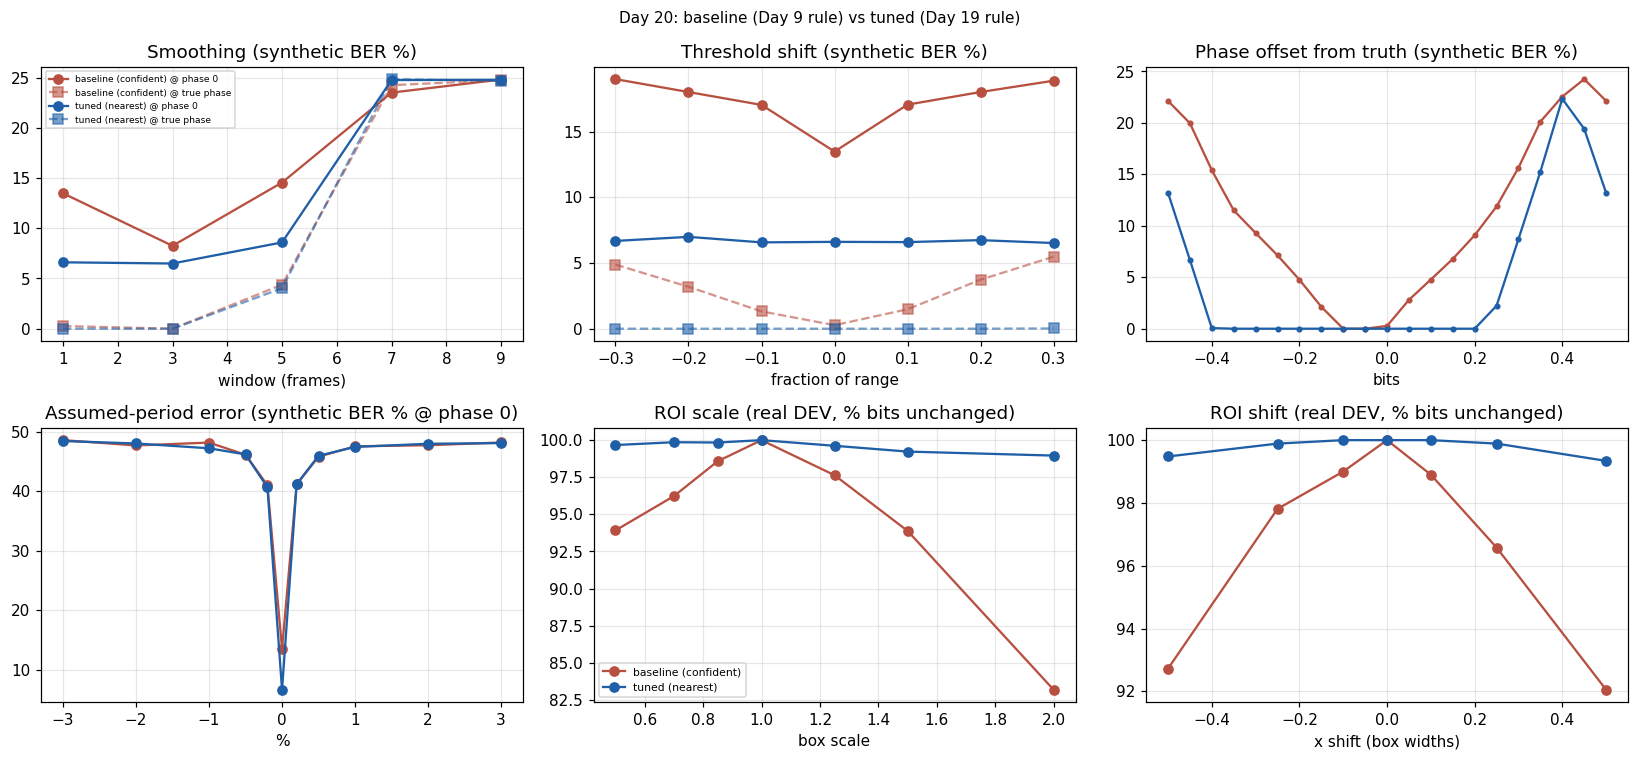

In [31]:
fig, ax = plt.subplots(2, 3, figsize=(15, 7)); col = {B: "#B85042", Tn: "#1f5fa8"}
for r in RULES:
    ax[0,0].plot(SMOOTH, [res['smoothing'][w][r][0] for w in SMOOTH], "o-", color=col[r], label=f"{r} @ phase 0")
    ax[0,0].plot(SMOOTH, [res['smoothing'][w][r][1] for w in SMOOTH], "s--", color=col[r], alpha=.6, label=f"{r} @ true phase")
    ax[0,1].plot(THR_SHIFT, [res['threshold'][d][r][0] for d in THR_SHIFT], "o-", color=col[r]); ax[0,1].plot(THR_SHIFT, [res['threshold'][d][r][1] for d in THR_SHIFT], "s--", color=col[r], alpha=.6)
    ax[0,2].plot(PHASE, [res['phase'][o][r] for o in PHASE], "o-", ms=3, color=col[r])
    es = sorted(res['period']); ax[1,0].plot(es, [res['period'][e][r][0] for e in es], "o-", color=col[r])
    ax[1,1].plot(ROI_SCALES, [ROI[f"scale {s_}"][r]["real_unchanged_pct"] for s_ in ROI_SCALES], "o-", color=col[r], label=r)
    ax[1,2].plot(ROI_SHIFTS, [ROI[f"shift x {s_:+.2f}"][r]["real_unchanged_pct"] for s_ in ROI_SHIFTS], "o-", color=col[r])
ax[0,0].set(title="Smoothing (synthetic BER %)", xlabel="window (frames)"); ax[0,0].legend(fontsize=6)
ax[0,1].set(title="Threshold shift (synthetic BER %)", xlabel="fraction of range")
ax[0,2].set(title="Phase offset from truth (synthetic BER %)", xlabel="bits")
ax[1,0].set(title="Assumed-period error (synthetic BER % @ phase 0)", xlabel="%")
ax[1,1].set(title="ROI scale (real DEV, % bits unchanged)", xlabel="box scale"); ax[1,1].legend(fontsize=7)
ax[1,2].set(title="ROI shift (real DEV, % bits unchanged)", xlabel="x shift (box widths)")
for a_ in ax.ravel(): a_.grid(alpha=.3)
fig.suptitle("Day 20: baseline (Day 9 rule) vs tuned (Day 19 rule)", fontsize=10); fig.tight_layout(); plt.show()

**In terms of the research question.** The tuned decoder changes under 1% of its bits for
a box half or double the size, a shift of half a box, a 3-frame smoother or a ±30% threshold
move; it decodes the model correctly across 60% of possible phases (the baseline: 5%). The
one sensitivity that matters is the **bit period**: a 0.2% rate error is a coin toss over
3,000 bits for every rule, phase known or not — the rate must be right to ~0.03%, and it is
not known to within 40%. Execution time never exceeds a millisecond per decode under any
condition. So the answer on this dataset is: *accurately enough that the settings do not
matter, provided the clock is known — and the clock is not known.* Everything above is
evidence on the assumed model plus consistency on the real data; the one hypothesis in play is
that the true clock is one of Day 14's beat candidates.

## 15. Day 21 — Best-candidate checkpoint: TEST opened once

> **Task.** Baseline vs tuned; robustness findings; representative successes and failures;
> remaining weaknesses (sync, decisions, noise, difficult segments, generalisation, unexplained
> errors); which improvements the evidence supports; risks; mentor approval for Week 4.
> **Delivered.** `week03/day21/`: `final_eval.py`, `final_eval.json`, `phase_band_all_rules.json`,
> `fig_final.png`, `DAY_21.MD`. Mentor approval: not recorded.

This is the first and only read of the TEST part (last 70% of every signal) with the
configurations frozen on Day 19.

In [32]:
from final_eval import DECODERS
RT = {}; BITS_T = {}
for name, kw in DECODERS.items():
    per = {k: indicators(sg, T92, fixed_thr, 12, kw["rule"], end_margin=kw["end_margin"]) for k, sg in TEST.items()}
    BITS_T[name] = {k: decode(sg, fixed_thr(sg), T92, 0.0, kw["rule"], kw["end_margin"])[0] for k, sg in TEST.items()}
    RT[name] = {m: float(np.median([per[k][m] for k in per])) for m in ("safe_pct", "phase_stability_pct", "threshold_tolerance_pct", "ones_pct", "flip_pct")}
agree = np.median([agreement(BITS_T["baseline (confident)"][k], BITS_T["tuned (nearest)"][k]) * 100 for k in TEST])
rng = np.random.default_rng(21); ST = {}
for name, kw in DECODERS.items():
    e0, et = [], []
    for nz in (8, 80):
        for seed in range(50, 54):
            b = random_bits(3000, seed); ph = float(rng.uniform(0, T92)); x = synth(b, phase=ph, exposure=0.3, noise=nz, seed=seed + 500); t = fixed_thr(x)
            e0.append((nz, ber(decode(x, t, T92, 0.0, kw['rule'], kw['end_margin'])[0], b)[0])); et.append((nz, ber(decode(x, t, T92, ph, kw['rule'], kw['end_margin'])[0], b)[0]))
    ST[name] = {nz: (np.mean([v for n_, v in e0 if n_ == nz]) * 100, np.mean([v for n_, v in et if n_ == nz]) * 100) for nz in (8, 80)}
print(f"{'decoder':22s} | TEST {'safe':>5s} {'ph-stab':>7s} {'thr-tol':>7s} {'ones':>5s} {'flips':>5s} | synth n8 BER@0/@true | n80 BER@0/@true")
for n in DECODERS:
    m = RT[n]; print(f"{n:22s} | {m['safe_pct']:5.1f} {m['phase_stability_pct']:7.1f} {m['threshold_tolerance_pct']:7.1f} {m['ones_pct']:5.1f} {m['flip_pct']:5.1f} | "
                     f"{ST[n][8][0]:6.2f} / {ST[n][8][1]:5.3f}     | {ST[n][80][0]:6.2f} / {ST[n][80][1]:5.2f}")
print(f"\nbaseline vs tuned agreement on TEST (median over lamps): {agree:.1f}%")
pb = json.load(open(REPO / "week03/day21/phase_band_all_rules.json"))
print("BER over a uniform phase sweep (validation streams):", {k: f"{v['mean_ber_over_all_phases_pct']}%  band {v['band']}" for k, v in pb.items()})

decoder                | TEST  safe ph-stab thr-tol  ones flips | synth n8 BER@0/@true | n80 BER@0/@true
baseline (confident)   |  44.4    89.6    75.2  47.1  46.0 |  12.71 / 0.208     |  11.87 /  1.97
tuned (nearest)        |  35.6    87.6    99.8  54.8  53.9 |   5.56 / 0.000     |   8.29 /  6.65
runner-up (average)    |  40.7    89.5    97.3  57.9  48.8 |   0.00 / 0.000     |  12.23 /  1.48

baseline vs tuned agreement on TEST (median over lamps): 79.2%
BER over a uniform phase sweep (validation streams): {'confident': '11.08%  band [-0.1, -0.0]', 'nearest': '4.82%  band [-0.4, 0.2]', 'average': '4.79%  band [-0.35, 0.25]'}


In [33]:
# where baseline and tuned disagree on 1LED TEST, and why
k = "1LED_92bps/lamp1"; sg = TEST[k]; thr = fixed_thr(sg)
bb, bt = BITS_T["baseline (confident)"][k], BITS_T["tuned (nearest)"][k]; n = min(len(bb), len(bt))
lo, hi = L.bit_windows(len(sg), T92, 0.0); span = float(np.ptp(sg))
both = np.array([(np.any(sg[lo[i]:hi[i]+1] > thr[0] + .35*span) and np.any(sg[lo[i]:hi[i]+1] < thr[0] - .35*span)) for i in range(n)])
dis = np.flatnonzero(bb[:n] != bt[:n])
print(f"1LED TEST: {len(dis)} of {n} bits differ ({len(dis)/n*100:.1f}%); {both[dis].mean()*100:.1f}% of them are windows holding both levels "
      f"(such windows are {both.mean()*100:.1f}% of all)\n")
print("six of them as frames  [one before] + window + [one after], threshold", int(thr[0]))
for i in dis[:6]:
    fr = [int(round(v)) for v in sg[max(0, lo[i]-1):hi[i]+2]]
    print(f"  bit {i:5d}: {str(fr):28s} baseline -> {bb[i]}   tuned -> {bt[i]}")
print("\nEvery disagreement is the same shape: two clean frames of different levels inside the assumed window.")
print("Which one belongs to *this* bit is unknowable without the phase. The tuned rule's advantage is statistical (right across 60% of phases), not per-bit.")

1LED TEST: 1448 of 6899 bits differ (21.0%); 97.3% of them are windows holding both levels (such windows are 48.8% of all)

six of them as frames  [one before] + window + [one after], threshold 125
  bit     1: [244, 249, 249, 2, 2]        baseline -> 0   tuned -> 1
  bit     6: [2, 250, 250, 2, 2]          baseline -> 0   tuned -> 1
  bit    14: [59, 2, 247, 247, 248]       baseline -> 0   tuned -> 1
  bit    21: [246, 4, 5, 250, 250]        baseline -> 1   tuned -> 0
  bit    32: [188, 250, 8, 2, 2]          baseline -> 1   tuned -> 0
  bit    34: [250, 2, 185, 250]           baseline -> 0   tuned -> 1

Every disagreement is the same shape: two clean frames of different levels inside the assumed window.
Which one belongs to *this* bit is unknowable without the phase. The tuned rule's advantage is statistical (right across 60% of phases), not per-bit.


**Reading the checkpoint.** Every indicator moved the way Day 19 predicted: the tuned
decoder's safe share is lower (35.6 vs 44.4%) and its phase stability 2 points lower — the
real-data indicators favour the baseline, and they are wrong to, because they measure how
little the output moves. The one that moves the right way is threshold tolerance, 75 → 99.8%.
The two decoders agree on 79% of TEST bits; 97% of the disagreements are windows holding both
levels.

**Nearest and average are the same decoder on the phase axis** (4.8% mean BER over a uniform
phase sweep, identical 0.65-bit bands; baseline 11.1%, 0.15 bit). Day 19's 0.4-point margin
between them was phase-draw noise. Average is better under noise at the true phase; nearest is
simpler and immune to the threshold. Either halves the baseline's error.

**Remaining weaknesses, in order.** (1) The bit period — everything above is conditional on
92.000 bps. (2) The phase — right across 60% of phases on the model; on the videos we do not
know which case we are in. (3) Noise at the true phase — the single-sample rule is worse than
the baseline at noise 80 (6.7 vs 2.0%); irrelevant at the real noise level. (4) No correctness
measurement on real data, unchanged since Day 7. (5) `2LEDs` L1 reads 56–61% ones under every
rule — unbalanced data or a systematic bias, unresolvable without truth.

**Week-4 direction proposed for approval.** Fix the clock first — the Day 14 beat (H5) to
better than 0.03%, or the transmitted bits for one video (Q1); then block-wise phase decoding
with the nearest rule, whose BER-vs-phase curve, unlike Day 15's, is not flat; then the full
reproduction run (E16) and the report. Not proposed: more threshold/ROI tuning (insensitive),
the classifier (inherits the phase problem, unverifiable), the adaptive threshold (redundant).

## 16. What the project established, Days 1 to 21

**Settled — measured from the videos, reproduced in a clean run**

| Finding | Evidence |
|---|---|
| 260 fps, steady, genuine content | Header and duration agree; no repeated frames (Day 7) |
| Camera static, no drift | Lamp moved under 1 px across a whole recording (Day 8) |
| Ambient light effectively constant | Varies about 0.1% of the lamp contrast (Day 8) |
| The signal is cleanly two-level | Gap about 245 against noise of 6 to 11 (Day 10) |
| Every lamp findable automatically; ROI choice does not matter | 1, 2, 3 and 4 lamps found; a box 0.5–2× or shifted half a width changes < 1% of tuned bits (Days 9, 20) |
| No cleaning step helps | All lower the separation; smoothing deletes real level changes (Day 12) |
| The pipeline is deterministic | Signal V1 byte-identical from the config; every report JSON regenerates identically (Days 11–21) |
| Lamps carry different data and share timing structure | 1-frame glitches coincide 2.3–3.9× chance; a shared clock is the leading explanation, a shared preamble not ruled out (Day 14) |
| The Day 9 sampling rule was the wrong one | Most-confident-frame: 12% BER at an unknown phase on the model, follows the threshold; nearest-frame: 6%, immune to it (Days 19–20) |
| The bit window over-reached | Last frame exposes inside the next bit at short exposure; end margin fixes it (Day 17) |
| Robustness | Insensitive to ROI, smoothing (≤ 3 frames) and threshold (±30%); phase band 0.6 bit (Day 20) |

**Not settled**

| Open | Status |
|---|---|
| The symbol clock | Fits a 92 bps grid 0.3% better than random times; no rate does better (Day 13). The beat points to ~82 / 91 / 124 / 136 bps (Day 14) |
| The bit period, to the precision needed | ±0.03% for 3,000 bits (Day 20); known to no better than 40% |
| What sits above the raw bits | Not plain text, not Manchester (Days 7, 10) |
| Whether any decoded bit is right | No ground truth. Only consistency can be measured, never correctness — and Day 19 showed consistency ranks the rules backwards |
| Mentor and peer decisions | Never recorded on any review day; blank templates in place |

**The honest state on Day 21.** A decoder that is stable, deterministic, fingerprinted and
insensitive to everything it controls, producing bit streams for all four videos — and unable
to say whether a single one of those bits is correct, because the bit clock could not be
recovered from the videos and no reference was supplied.

**What would settle everything.** The transmitted bits for a single video. With those, the
correct phase and period are whichever reproduce them, and every open row above collapses into
a measurement.